<a href="https://colab.research.google.com/github/gabrielqueeiroz/breast-cancer-ensemble-learning/blob/main/ensemble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, recall_score, precision_score
import numpy as np
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
import re

# Ler dataset

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
df_pam50_completo = pd.read_csv('/content/drive/MyDrive/Database/brca_metabric/df_MI_no_missing.csv', index_col=0)
X_df_pam50_completo = df_pam50_completo.drop(columns=["PAM50"])
y_df_pam50_completo = df_pam50_completo["PAM50"]


In [ ]:
df_pam50_completo.head()

,ACTR3B,ANLN,BAG1,BCL2,BIRC5,BLVRA,CCNB1,CCNE1,CDC20,CDC6,...,PHGDH,PTTG1,RRM2,SFRP1,SLC39A6,TMEM45B,TYMS,UBE2C,UBE2T,PAM50
0,0.8121,-2.3945,-1.3461,-1.2152,-0.4477,-0.1063,-0.4026,-1.4527,-2.6631,0.2191,...,-4.9736,-2.1383,-1.4187,-4.1152,4.3368,-0.0520,-0.6288,0.5993,-1.1400,LumA
1,2.1088,3.1000,-2.1653,-1.7849,1.2259,-0.9976,2.4479,2.4708,1.3445,1.6558,...,-0.3164,2.6156,2.7519,2.5545,-2.9671,-5.7626,1.6063,1.5744,2.5475,Basal
2,-1.7567,0.1252,2.3103,-1.0638,-1.5415,-1.3820,-3.0226,-2.2897,-0.1800,-3.9807,...,-4.2280,-1.3611,-3.0675,-5.6948,-0.9732,7.2015,-2.7205,-1.0958,-2.3661,LumA
3,0.9554,1.1368,-0.5680,-2.3695,0.9350,0.4742,0.5331,1.3280,0.6394,0.2160,...,1.5404,0.7889,-0.1398,-3.1952,-0.9300,-3.8243,0.1802,1.3494,-0.1096,Basal
4,1.7797,2.6335,0.6886,-0.6260,1.9677,-0.6331,3.1293,3.0898,2.8617,2.1273,...,2.2834,3.0739,2.1254,-7.3423,-2.8209,-2.2993,2.8119,3.0335,1.9988,Basal


In [ ]:
df_pam50_completo['PAM50'].value_counts()

,count
PAM50,
LumA,57
Basal,29
LumB,17
Her2,14


In [ ]:
print(df_pam50_completo.isnull().sum().sum())

0


# Método para inserção de valores faltantes

In [14]:
import numpy as np
import pandas as pd

def add_missing_values(df, missing_rate=0.1, seed=None):
    rng = np.random.default_rng(seed)
    mask = rng.random(df.shape) < missing_rate
    df_missing = df.copy()
    df_missing.values[mask] = np.nan
    return df_missing, mask


missing_rates = [0.0, 0.05, 0.10, 0.20, 0.30]
n_replicates = 10
X_missing_sets = {}
mask_sets = {}

for rate in missing_rates:
    X_missing_sets[rate] = []
    mask_sets[rate] = []

    for rep in range(n_replicates):
        seed = 1000 + rep + int(rate*100)
        X_missing, mask = add_missing_values(
            X_df_pam50_completo,
            missing_rate=rate,
            seed=seed
        )

        X_missing_sets[rate].append(X_missing)
        mask_sets[rate].append(mask)

In [ ]:
X_missing_sets[0.05][0]

,ACTR3B,ANLN,BAG1,BCL2,BIRC5,BLVRA,CCNB1,CCNE1,CDC20,CDC6,...,PGR,PHGDH,PTTG1,RRM2,SFRP1,SLC39A6,TMEM45B,TYMS,UBE2C,UBE2T
0,0.8121,-2.3945,-1.3461,-1.2152,-0.4477,-0.1063,-0.4026,-1.4527,-2.6631,0.2191,...,-0.4217,-4.9736,-2.1383,-1.4187,-4.1152,4.3368,-0.0520,-0.62880,0.5993,-1.1400
1,2.1088,3.1000,-2.1653,-1.7849,NaN,-0.9976,2.4479,2.4708,1.3445,1.6558,...,-5.4723,-0.3164,2.6156,2.7519,2.5545,-2.9671,-5.7626,1.60630,1.5744,2.5475
2,-1.7567,0.1252,2.3103,-1.0638,-1.5415,-1.3820,-3.0226,-2.2897,-0.1800,-3.9807,...,6.0620,-4.2280,-1.3611,-3.0675,-5.6948,-0.9732,7.2015,-2.72050,-1.0958,-2.3661
3,0.9554,1.1368,-0.5680,-2.3695,0.9350,0.4742,0.5331,1.3280,0.6394,0.2160,...,-5.7817,NaN,0.7889,-0.1398,-3.1952,-0.9300,-3.8243,0.18020,1.3494,-0.1096
4,1.7797,2.6335,0.6886,NaN,1.9677,-0.6331,NaN,3.0898,2.8617,2.1273,...,-5.4469,2.2834,3.0739,2.1254,-7.3423,-2.8209,-2.2993,2.81190,3.0335,1.9988
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,3.2071,1.2313,1.0114,-2.7507,0.8054,-1.7707,0.8570,1.4661,2.1507,0.5427,...,-4.1871,2.8573,1.0285,0.1905,5.5610,-2.2058,-6.2327,1.63290,0.4726,0.7208
113,0.6599,-3.5138,0.2944,0.7111,-5.6848,-0.6513,-3.6704,-3.1597,-6.0416,-5.0105,...,1.5452,-1.5393,-5.4252,-4.5941,6.1585,0.9913,2.0394,-0.00235,-4.9425,-2.7816
114,-1.7878,-0.3250,-1.7188,0.8916,0.3778,0.6960,0.5306,0.5381,-0.1107,0.2179,...,4.3155,-1.6357,0.3594,-0.1301,-7.1723,2.8939,-0.8243,-0.00800,0.4968,1.6253
115,1.1594,1.8437,-1.1435,-2.4411,1.3091,-0.6389,0.9276,1.5031,-0.4716,0.5012,...,-4.3013,0.3291,1.5058,2.1196,4.1878,-1.5073,-4.2797,0.43970,1.8333,1.8435


In [ ]:
for rate in X_missing_sets.keys():
    print(rate, type(X_missing_sets[rate]))

0.0 <class 'list'>
0.05 <class 'list'>
0.1 <class 'list'>
0.2 <class 'list'>
0.3 <class 'list'>


## Verificação da qualidade de inserção

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.base import clone

def imputation_scores_cv(X_full, X_missing, mask, y, imputer, cv):
    """
    Avalia imputação SEM leakage:
    - fit imputer no treino (com missing)
    - transform no teste
    - calcula métricas apenas onde mask==True no TESTE
    """
    rmses, maes = [], []

    X_full = np.asarray(X_full, dtype=float)
    X_missing = np.asarray(X_missing, dtype=float)
    mask = np.asarray(mask, dtype=bool)
    y = np.asarray(pd.Series(y).squeeze())

    for train_idx, test_idx in cv.split(X_missing, y):
        X_train = X_missing[train_idx]
        X_test  = X_missing[test_idx]

        # Fit no treino, transform no teste
        imp = clone(imputer)
        imp.fit(X_train)
        X_test_imp = imp.transform(X_test)

        # Avalia APENAS posições mascaradas no teste
        m_test = mask[test_idx]
        true_vals = X_full[test_idx][m_test]
        pred_vals = X_test_imp[m_test]

        diff = pred_vals - true_vals
        rmse = float(np.sqrt(np.mean(diff**2)))
        mae  = float(np.mean(np.abs(diff)))

        rmses.append(rmse)
        maes.append(mae)

    return {
        "rmse_mean": float(np.mean(rmses)),
        "rmse_std": float(np.std(rmses, ddof=1)),
        "mae_mean": float(np.mean(maes)),
        "mae_std": float(np.std(maes, ddof=1)),
    }

# Exemplo de uso:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Para um cenário específico (ex.: 10% missing, rep 0)
rate, rep = 0.10, 0
X_full = X_df_pam50_completo          # sem NaN
X_missing = X_missing_sets[rate][rep] # com NaN
mask = mask_sets[rate][rep]           # True onde você removeu
y = y_df_pam50_completo

scores_knn = imputation_scores_cv(
    X_full, X_missing, mask, y,
    imputer=KNNImputer(n_neighbors=5, weights="distance"),
    cv=cv
)
print(scores_knn)

{'rmse_mean': 1.8691130122277055, 'rmse_std': 0.12164073093042668, 'mae_mean': 1.3047519981913704, 'mae_std': 0.100099672832686}


In [ ]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer, KNNImputer


def imputation_scores_cv(
    X_full,
    X_missing,
    mask,
    y,
    imputer,
    cv,
    imputer_name=None,
    missing_rate=None,
    replicate=None,
):
    """
    Avalia imputação sem leakage via CV estratificada.

    Parâmetros
    ----------
    X_full : array-like ou DataFrame
        Dataset completo, sem NaN, usado como ground truth.
    X_missing : array-like ou DataFrame
        Dataset com valores removidos artificialmente.
    mask : array-like bool
        Máscara booleana do mesmo shape de X_missing.
        True indica posição removida artificialmente.
    y : array-like
        Rótulos para estratificação dos folds.
    imputer : estimador sklearn-like
        Imputador com fit/transform.
    cv : splitter
        Ex.: StratifiedKFold(...)
    imputer_name : str, opcional
        Nome do imputador para registrar no output.
    missing_rate : float, opcional
        Taxa de missing para registrar no output.
    replicate : int, opcional
        Índice da repetição para registrar no output.

    Retorna
    -------
    raw_df : DataFrame
        Resultado por fold.
    summary_dict : dict
        Estatísticas agregadas.
    """

    X_full = np.asarray(X_full, dtype=float)
    X_missing = np.asarray(X_missing, dtype=float)
    mask = np.asarray(mask, dtype=bool)
    y = np.asarray(pd.Series(y).squeeze())

    if X_full.shape != X_missing.shape:
        raise ValueError("X_full e X_missing devem ter o mesmo shape.")
    if X_full.shape != mask.shape:
        raise ValueError("mask deve ter o mesmo shape de X_full/X_missing.")
    if X_full.shape[0] != len(y):
        raise ValueError("Número de amostras em X e y deve coincidir.")

    rows = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X_missing, y), start=1):
        X_train = X_missing[train_idx]
        X_test = X_missing[test_idx]

        # Clona o imputador para evitar vazamento/estado compartilhado entre folds
        imp = clone(imputer)
        imp.fit(X_train)
        X_test_imp = imp.transform(X_test)

        # Avalia apenas posições mascaradas no teste
        m_test = mask[test_idx]

        true_vals = X_full[test_idx][m_test]
        pred_vals = X_test_imp[m_test]

        # Caso raro: nenhum valor mascarado nesse fold
        if true_vals.size == 0:
            rmse = np.nan
            mae = np.nan
            n_masked = 0
        else:
            diff = pred_vals - true_vals
            rmse = float(np.sqrt(np.mean(diff ** 2)))
            mae = float(np.mean(np.abs(diff)))
            n_masked = int(true_vals.size)

        rows.append({
            "imputer": imputer_name,
            "missing_rate": missing_rate,
            "replicate": replicate,
            "fold": fold,
            "rmse": rmse,
            "mae": mae,
            "n_masked_test_values": n_masked,
        })

    raw_df = pd.DataFrame(rows)

    summary_dict = {
        "imputer": imputer_name,
        "missing_rate": missing_rate,
        "replicate": replicate,
        "rmse_mean": float(raw_df["rmse"].mean(skipna=True)),
        "rmse_std": float(raw_df["rmse"].std(skipna=True, ddof=1)),
        "mae_mean": float(raw_df["mae"].mean(skipna=True)),
        "mae_std": float(raw_df["mae"].std(skipna=True, ddof=1)),
        "folds": int(raw_df["fold"].nunique()),
        "total_masked_test_values": int(raw_df["n_masked_test_values"].sum()),
    }

    return raw_df, summary_dict

In [ ]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer, KNNImputer


def imputation_scores_cv(
    X_full,
    X_missing,
    mask,
    y,
    imputer,
    cv,
    imputer_name=None,
    missing_rate=None,
    replicate=None,
):
    """
    Avalia imputação sem leakage via CV estratificada.
    Retorna:
      - raw_df: métricas por fold
      - summary_dict: resumo agregado do cenário
    """
    X_full = np.asarray(X_full, dtype=float)
    X_missing = np.asarray(X_missing, dtype=float)
    mask = np.asarray(mask, dtype=bool)
    y = np.asarray(pd.Series(y).squeeze())

    if X_full.shape != X_missing.shape:
        raise ValueError("X_full e X_missing devem ter o mesmo shape.")
    if X_full.shape != mask.shape:
        raise ValueError("mask deve ter o mesmo shape de X_full/X_missing.")
    if X_full.shape[0] != len(y):
        raise ValueError("Número de amostras em X e y deve coincidir.")

    rows = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X_missing, y), start=1):
        X_train = X_missing[train_idx]
        X_test = X_missing[test_idx]

        imp = clone(imputer)
        imp.fit(X_train)
        X_test_imp = np.asarray(imp.transform(X_test), dtype=float)

        m_test = mask[test_idx]

        true_vals = X_full[test_idx][m_test]
        pred_vals = X_test_imp[m_test]

        if true_vals.size == 0:
            rmse = np.nan
            mae = np.nan
            n_masked = 0
        else:
            diff = pred_vals - true_vals
            rmse = float(np.sqrt(np.mean(diff ** 2)))
            mae = float(np.mean(np.abs(diff)))
            n_masked = int(true_vals.size)

        rows.append({
            "imputer": imputer_name,
            "missing_rate": missing_rate,
            "replicate": replicate,
            "fold": fold,
            "rmse": rmse,
            "mae": mae,
            "n_masked_test_values": n_masked,
        })

    raw_df = pd.DataFrame(rows)

    summary_dict = {
        "imputer": imputer_name,
        "missing_rate": missing_rate,
        "replicate": replicate,
        "rmse_mean": float(raw_df["rmse"].mean(skipna=True)),
        "rmse_std": float(raw_df["rmse"].std(skipna=True, ddof=1)),
        "mae_mean": float(raw_df["mae"].mean(skipna=True)),
        "mae_std": float(raw_df["mae"].std(skipna=True, ddof=1)),
        "folds": int(raw_df["fold"].nunique()),
        "total_masked_test_values": int(raw_df["n_masked_test_values"].sum()),
    }

    return raw_df, summary_dict


def run_all_imputation_experiments(
    X_full,
    y,
    X_missing_sets,
    mask_sets,
    imputers,
    cv,
    verbose=True,
):
    """
    Executa todos os imputadores em todos os cenários:
      - cada missing_rate
      - cada replicate
      - cada imputador

    Espera estruturas como:
      X_missing_sets[rate][rep]
      mask_sets[rate][rep]
    """
    all_raw = []
    all_summary = []

    rates = sorted(X_missing_sets.keys())

    for rate in rates:
        n_reps = len(X_missing_sets[rate])

        for rep in range(n_reps):
            X_missing = X_missing_sets[rate][rep]
            mask = mask_sets[rate][rep]

            for imputer_name, imputer_obj in imputers.items():
                if verbose:
                    print(f"Running | imputer={imputer_name} | missing_rate={rate} | replicate={rep}")

                raw_df, summary_dict = imputation_scores_cv(
                    X_full=X_full,
                    X_missing=X_missing,
                    mask=mask,
                    y=y,
                    imputer=imputer_obj,
                    cv=cv,
                    imputer_name=imputer_name,
                    missing_rate=rate,
                    replicate=rep,
                )

                all_raw.append(raw_df)
                all_summary.append(pd.DataFrame([summary_dict]))

    imp_raw_cv = pd.concat(all_raw, ignore_index=True)
    imp_summary_cv = pd.concat(all_summary, ignore_index=True)

    return imp_raw_cv, imp_summary_cv

#exec

# Experimento: Avaliação de inserção e classificação de subtipo

In [10]:
import os
import json
from datetime import datetime

import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVR, SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier


# -------------------------
# 0) Artefatos
# -------------------------
def make_run_dir(root="artifacts", tag="pam50"):
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_dir = os.path.join(root, f"{tag}_{ts}")
    os.makedirs(run_dir, exist_ok=True)
    return run_dir


def save_df(df: pd.DataFrame, run_dir: str, name: str):
    path = os.path.join(run_dir, name)
    df.to_csv(path, index=False)
    print("Saved:", path)


def save_json(obj: dict, run_dir: str, name: str):
    path = os.path.join(run_dir, name)
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)
    print("Saved:", path)


# -------------------------
# 1) RFECA Imputer (SVR)
# -------------------------
class RFECAImputerSVR(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        corr_csv_path: str,
        top_k: int = 20,
        use_abs_corr: bool = True,
        kernel: str = "linear",
        C: float = 1.0,
        epsilon: float = 0.1,
        min_train_samples: int = 10,
        fallback_strategy: str = "mean",
        feature_names: list | None = None,
    ):
        self.corr_csv_path = corr_csv_path
        self.top_k = top_k
        self.use_abs_corr = use_abs_corr
        self.kernel = kernel
        self.C = C
        self.epsilon = epsilon
        self.min_train_samples = min_train_samples
        self.fallback_strategy = fallback_strategy
        self.feature_names = feature_names

    def _to_dataframe(self, X):
        if isinstance(X, pd.DataFrame):
            X_df = X.copy()
            X_df.columns = X_df.columns.astype(str)
            return X_df

        if self.feature_names is not None:
            return pd.DataFrame(X, columns=[str(c) for c in self.feature_names]).copy()

        raise ValueError(
            "X foi fornecido como ndarray e nenhum feature_names foi informado. "
            "Passe X como DataFrame ou defina feature_names no imputador."
        )

    def fit(self, X, y=None):
        X_df = self._to_dataframe(X)
        self.feature_names_in_ = list(X_df.columns)

        corr = pd.read_csv(self.corr_csv_path, index_col=0)
        corr.index = corr.index.astype(str)
        corr.columns = corr.columns.astype(str)
        corr = corr.reindex(index=self.feature_names_in_, columns=self.feature_names_in_)

        if self.fallback_strategy == "zero":
            self._fallback_values_ = pd.Series(0.0, index=self.feature_names_in_)
        else:
            self._fallback_values_ = X_df.mean(axis=0)

        self._top_features_ = {}

        for gene in self.feature_names_in_:
            if gene not in corr.index:
                self._top_features_[gene] = []
                continue

            s = corr.loc[gene].drop(labels=[gene], errors="ignore").dropna()

            if self.use_abs_corr:
                s = s.reindex(s.abs().sort_values(ascending=False).index)
            else:
                s = s.sort_values(ascending=False)

            self._top_features_[gene] = list(s.index[: self.top_k])

        return self

    def transform(self, X):
        X_df = self._to_dataframe(X)
        X_df = X_df.reindex(columns=self.feature_names_in_)

        for gene, predictors in self._top_features_.items():
            miss = X_df[gene].isna()
            if miss.sum() == 0:
                continue

            obs = ~miss

            if obs.sum() < self.min_train_samples or len(predictors) == 0:
                X_df[gene] = self._fallback_fill(X_df[gene], gene)
                continue

            valid_predictors = [p for p in predictors if p in X_df.columns]
            if len(valid_predictors) == 0:
                X_df[gene] = self._fallback_fill(X_df[gene], gene)
                continue

            X_train = X_df.loc[obs, valid_predictors].to_numpy(dtype=float)
            y_train = X_df.loc[obs, gene].to_numpy(dtype=float)
            X_pred = X_df.loc[miss, valid_predictors].to_numpy(dtype=float)

            imp = SimpleImputer(strategy="mean")
            X_train = imp.fit_transform(X_train)
            X_pred = imp.transform(X_pred)

            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_pred = scaler.transform(X_pred)

            model = SVR(kernel=self.kernel, C=self.C, epsilon=self.epsilon)

            try:
                model.fit(X_train, y_train)
                y_hat = model.predict(X_pred)
                X_df.loc[miss, gene] = y_hat
            except Exception:
                X_df[gene] = self._fallback_fill(X_df[gene], gene)

        return X_df

    def _fallback_fill(self, s: pd.Series, gene: str) -> pd.Series:
        fill_value = self._fallback_values_.get(gene, 0.0)
        return s.fillna(fill_value)


# -------------------------
# 2) EXP1: imputação sem leakage
# -------------------------
def imputation_scores_cv(
    X_full,
    X_missing,
    mask,
    y,
    imputer,
    cv,
    imputer_name=None,
    missing_rate=None,
    replicate=None,
):
    X_full = np.asarray(X_full, dtype=float)
    X_missing = np.asarray(X_missing, dtype=float)
    mask = np.asarray(mask, dtype=bool)
    y = np.asarray(pd.Series(y).squeeze())

    rows = []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X_missing, y), start=1):
        X_train = X_missing[train_idx]
        X_test = X_missing[test_idx]

        imp = clone(imputer)
        imp.fit(X_train)
        X_test_imp = np.asarray(imp.transform(X_test), dtype=float)

        m_test = mask[test_idx]

        true_vals = X_full[test_idx][m_test]
        pred_vals = X_test_imp[m_test]

        if true_vals.size == 0:
            rmse = np.nan
            mae = np.nan
            n_masked = 0
        else:
            diff = pred_vals - true_vals
            rmse = float(np.sqrt(np.mean(diff ** 2)))
            mae = float(np.mean(np.abs(diff)))
            n_masked = int(true_vals.size)

        rows.append({
            "imputer": imputer_name,
            "missing_rate": missing_rate,
            "replicate": replicate,
            "fold": fold,
            "rmse": rmse,
            "mae": mae,
            "n_masked_test_values": n_masked,
        })

    raw_df = pd.DataFrame(rows)

    summary_dict = {
        "imputer": imputer_name,
        "missing_rate": missing_rate,
        "replicate": replicate,
        "rmse_mean": float(raw_df["rmse"].mean(skipna=True)),
        "rmse_std": float(raw_df["rmse"].std(skipna=True, ddof=1)),
        "mae_mean": float(raw_df["mae"].mean(skipna=True)),
        "mae_std": float(raw_df["mae"].std(skipna=True, ddof=1)),
        "folds": int(raw_df["fold"].nunique()),
        "total_masked_test_values": int(raw_df["n_masked_test_values"].sum()),
    }

    return raw_df, summary_dict


def run_all_imputation_experiments(
    X_full,
    y,
    X_missing_sets,
    mask_sets,
    imputers,
    cv,
    verbose=True,
    max_reps=None,
):
    all_raw = []
    all_summary = []

    rates = sorted(X_missing_sets.keys())

    for rate in rates:
        n_reps_available = len(X_missing_sets[rate])
        n_reps_to_run = n_reps_available if max_reps is None else min(max_reps, n_reps_available)

        for rep in range(n_reps_to_run):
            X_missing = X_missing_sets[rate][rep]
            mask = mask_sets[rate][rep]

            for imputer_name, imputer_obj in imputers.items():
                if verbose:
                    print(f"Running | imputer={imputer_name} | missing_rate={rate} | replicate={rep}")

                raw_df, summary_dict = imputation_scores_cv(
                    X_full=X_full,
                    X_missing=X_missing,
                    mask=mask,
                    y=y,
                    imputer=imputer_obj,
                    cv=cv,
                    imputer_name=imputer_name,
                    missing_rate=rate,
                    replicate=rep,
                )

                all_raw.append(raw_df)
                all_summary.append(pd.DataFrame([summary_dict]))

    imp_raw_cv = pd.concat(all_raw, ignore_index=True)
    imp_summary_cv = pd.concat(all_summary, ignore_index=True)

    return imp_raw_cv, imp_summary_cv


# -------------------------
# 3) EXP2: classificação
# -------------------------
def make_pipelines_with_imputer(imputer, random_state=42):
    pipeline_svc = Pipeline([
        ("imputer", imputer),
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=random_state))
    ])

    pipeline_lr = Pipeline([
        ("imputer", imputer),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, multi_class="auto"))
    ])

    pipeline_rf = Pipeline([
        ("imputer", imputer),
        ("clf", RandomForestClassifier(n_estimators=200, random_state=random_state))
    ])

    pipeline_gb = Pipeline([
        ("imputer", imputer),
        ("clf", GradientBoostingClassifier(random_state=random_state))
    ])

    svc_soft = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=random_state))
    ])

    svc_hard = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=random_state))
    ])

    lr_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(max_iter=5000, multi_class="auto"))
    ])

    rf_pipe = RandomForestClassifier(n_estimators=200, random_state=random_state)
    gb_pipe = GradientBoostingClassifier(random_state=random_state)

    ensemble_soft = VotingClassifier(
        estimators=[
            ("svc", svc_soft),
            ("lr", lr_pipe),
            ("rf", rf_pipe),
            ("gb", gb_pipe),
        ],
        voting="soft"
    )

    ensemble_hard = VotingClassifier(
        estimators=[
            ("svc", svc_hard),
            ("lr", lr_pipe),
            ("rf", rf_pipe),
            ("gb", gb_pipe),
        ],
        voting="hard"
    )

    pipeline_ensemble_soft = Pipeline([
        ("imputer", imputer),
        ("clf", ensemble_soft)
    ])

    pipeline_ensemble_hard = Pipeline([
        ("imputer", imputer),
        ("clf", ensemble_hard)
    ])

    return {
        "SVC": pipeline_svc,
        "LogReg": pipeline_lr,
        "RF": pipeline_rf,
        "GB": pipeline_gb,
        "EnsembleSoft": pipeline_ensemble_soft,
        "EnsembleHard": pipeline_ensemble_hard,
    }


def exp2_classification(
    X_missing_sets: dict,
    y,
    imputers: dict,
    missing_rates=None,
    n_splits=5,
    random_state=42,
    n_jobs=-1,
    skip_zero_missing=False,
    max_reps=None,
):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    y = pd.Series(y).squeeze()

    scorers = {
        "f1_macro": "f1_macro",
        "bal_acc": "balanced_accuracy",
    }

    rows = []

    if missing_rates is None:
        missing_rates = sorted(X_missing_sets.keys())

    if skip_zero_missing:
        missing_rates = [r for r in missing_rates if r > 0]

    for imp_name, imputer in imputers.items():
        pipelines = make_pipelines_with_imputer(imputer, random_state=random_state)

        for rate in missing_rates:
            n_reps_available = len(X_missing_sets[rate])
            n_reps_to_run = n_reps_available if max_reps is None else min(max_reps, n_reps_available)

            for rep in range(n_reps_to_run):
                X_missing = X_missing_sets[rate][rep]

                print(f"{imp_name} | rate={rate} | rep={rep}")

                for model_name, pipe in pipelines.items():
                    out = cross_validate(
                        pipe,
                        X_missing,
                        y,
                        cv=cv,
                        scoring=scorers,
                        n_jobs=n_jobs,
                        return_train_score=False
                    )

                    rows.append({
                        "imputer": imp_name,
                        "missing_rate": rate,
                        "replicate": rep,
                        "model": model_name,
                        "f1_macro": float(np.mean(out["test_f1_macro"])),
                        "bal_acc": float(np.mean(out["test_bal_acc"])),
                    })

    results = pd.DataFrame(rows)

    summary = (
        results
        .groupby(["imputer", "missing_rate", "model"])
        .agg(
            f1_mean=("f1_macro", "mean"),
            f1_std=("f1_macro", "std"),
            bal_mean=("bal_acc", "mean"),
            bal_std=("bal_acc", "std"),
            n=("f1_macro", "count"),
        )
        .reset_index()
        .sort_values(["imputer", "missing_rate", "f1_mean"], ascending=[True, True, False])
    )

    summary["f1_pm_std"] = (
        summary["f1_mean"].map(lambda v: f"{v:.4f}") + " ± " +
        summary["f1_std"].map(lambda v: f"{v:.4f}")
    )

    summary["bal_pm_std"] = (
        summary["bal_mean"].map(lambda v: f"{v:.4f}") + " ± " +
        summary["bal_std"].map(lambda v: f"{v:.4f}")
    )

    return results, summary


# -------------------------
# 4) Orquestrador
# -------------------------
def run_all_and_save(
    X_df_pam50_completo,
    y_df_pam50_completo,
    X_missing_sets,
    mask_sets,
    corr_csv_path="correlation_table_pam50_full.csv",
    missing_rates_exp1=(0.05, 0.10, 0.20, 0.30),
    missing_rates_exp2=(0.0, 0.05, 0.10, 0.20, 0.30),
    n_splits=5,
    random_state=42,
    n_jobs=-1,
    verbose=True,
    max_reps=None,
):
    run_dir = make_run_dir(root="artifacts", tag="pam50")

    imputers = {
        "SimpleMean": SimpleImputer(strategy="mean"),
        "KNN(k=5,dist)": KNNImputer(n_neighbors=5, weights="distance"),
        "RFECA_SVR(k=5)": RFECAImputerSVR(
            corr_csv_path=corr_csv_path,
            top_k=5,
            feature_names=X_df_pam50_completo.columns.tolist(),
        ),
        "RFECA_SVR(k=10)": RFECAImputerSVR(
            corr_csv_path=corr_csv_path,
            top_k=10,
            feature_names=X_df_pam50_completo.columns.tolist(),
        ),
        "RFECA_SVR(k=20)": RFECAImputerSVR(
            corr_csv_path=corr_csv_path,
            top_k=20,
            feature_names=X_df_pam50_completo.columns.tolist(),
        ),
    }

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    X_missing_sets_exp1 = {
        rate: X_missing_sets[rate]
        for rate in missing_rates_exp1
        if rate in X_missing_sets
    }

    mask_sets_exp1 = {
        rate: mask_sets[rate]
        for rate in missing_rates_exp1
        if rate in mask_sets
    }

    exp1_raw, exp1_summary = run_all_imputation_experiments(
        X_full=X_df_pam50_completo,
        y=y_df_pam50_completo,
        X_missing_sets=X_missing_sets_exp1,
        mask_sets=mask_sets_exp1,
        imputers=imputers,
        cv=cv,
        verbose=verbose,
        max_reps=max_reps,
    )

    exp1_summary = exp1_summary[exp1_summary["missing_rate"] > 0].copy()

    exp2_raw, exp2_summary = exp2_classification(
        X_missing_sets=X_missing_sets,
        y=y_df_pam50_completo,
        imputers=imputers,
        missing_rates=missing_rates_exp2,
        n_splits=n_splits,
        random_state=random_state,
        n_jobs=n_jobs,
        skip_zero_missing=False,
        max_reps=max_reps,
    )

    save_df(exp1_raw, run_dir, "exp1_imputation_raw_cv.csv")
    save_df(exp1_summary, run_dir, "exp1_imputation_summary_cv.csv")
    save_df(exp2_raw, run_dir, "exp2_classification_raw.csv")
    save_df(exp2_summary, run_dir, "exp2_classification_summary.csv")

    meta = {
        "corr_csv_path": corr_csv_path,
        "n_splits": n_splits,
        "random_state": random_state,
        "max_reps": max_reps,
        "missing_rates_exp1": list(missing_rates_exp1),
        "missing_rates_exp2": list(missing_rates_exp2),
        "imputers": list(imputers.keys()),
        "exp2_models": ["SVC", "LogReg", "RF", "GB", "EnsembleSoft", "EnsembleHard"],
        "rfeca": {
            "top_k_values": [5, 10, 20],
            "use_abs_corr": True,
            "svr_kernel": "linear",
            "C": 1.0,
            "epsilon": 0.1,
            "min_train_samples": 10,
        },
    }
    save_json(meta, run_dir, "metadata.json")

    print("\n[EXP1] Imputation table:")
    print(exp1_summary.head(20))

    print("\n[EXP2] Classification table (top 60 rows):")
    print(exp2_summary.head(60))

    print("\nArtifacts saved at:", run_dir)
    return run_dir, exp1_summary, exp2_summary

## Rodada completa

In [ ]:
run_dir, exp1_table, exp2_table = run_all_and_save(
    X_df_pam50_completo=X_df_pam50_completo,
    y_df_pam50_completo=y_df_pam50_completo,
    X_missing_sets=X_missing_sets,
    mask_sets=mask_sets,
    corr_csv_path="correlation_table_pam50_full.csv",
    n_splits=5,
    random_state=42,
    n_jobs=-1,
    max_reps=None,
)

Running | imputer=SimpleMean | missing_rate=0.05 | replicate=0
Running | imputer=KNN(k=5,dist) | missing_rate=0.05 | replicate=0
Running | imputer=RFECA_SVR(k=5) | missing_rate=0.05 | replicate=0
Running | imputer=RFECA_SVR(k=10) | missing_rate=0.05 | replicate=0
Running | imputer=RFECA_SVR(k=20) | missing_rate=0.05 | replicate=0
Running | imputer=SimpleMean | missing_rate=0.05 | replicate=1
Running | imputer=KNN(k=5,dist) | missing_rate=0.05 | replicate=1
Running | imputer=RFECA_SVR(k=5) | missing_rate=0.05 | replicate=1
Running | imputer=RFECA_SVR(k=10) | missing_rate=0.05 | replicate=1
Running | imputer=RFECA_SVR(k=20) | missing_rate=0.05 | replicate=1
Running | imputer=SimpleMean | missing_rate=0.05 | replicate=2
Running | imputer=KNN(k=5,dist) | missing_rate=0.05 | replicate=2
Running | imputer=RFECA_SVR(k=5) | missing_rate=0.05 | replicate=2
Running | imputer=RFECA_SVR(k=10) | missing_rate=0.05 | replicate=2
Running | imputer=RFECA_SVR(k=20) | missing_rate=0.05 | replicate=2
Runn

## Rodada rápida

In [ ]:
run_dir, exp1_table, exp2_table = run_all_and_save(
    X_df_pam50_completo=X_df_pam50_completo,
    y_df_pam50_completo=y_df_pam50_completo,
    X_missing_sets=X_missing_sets,
    mask_sets=mask_sets,
    corr_csv_path="correlation_table_pam50_full.csv",
    missing_rates_exp1=(0.05,),
    missing_rates_exp2=(0.0, 0.05),
    n_splits=3,
    random_state=42,
    n_jobs=-1,
    max_reps=2,
)

In [ ]:
# -------------------------
# 4) Orquestrador (RFECA only): roda tudo e salva
# -------------------------
def run_rfeca_only_and_save(
    X_df_pam50_completo,
    y_df_pam50_completo,
    X_missing_sets,
    mask_sets,
    corr_csv_path="correlation_table_pam50_full.csv",
    top_k=20,
    missing_rates_exp1=(0.05, 0.10, 0.20, 0.30),
    # missing_rates_exp2=(0.0, 0.05, 0.10, 0.20, 0.30),
    missing_rates_exp2=(0.0,),
    n_reps=10,
    n_splits=5,
    random_state=42,
    n_jobs=-1
):
    run_dir = make_run_dir(root="artifacts", tag=f"pam50_rfeca_k{top_k}")

    rfeca_name = f"RFECA_SVR(k={top_k})"

    imputers = {
        rfeca_name: RFECAImputerSVR(
            corr_csv_path=corr_csv_path,
            top_k=top_k,
            use_abs_corr=True,
            kernel="linear",
            C=1.0,
            epsilon=0.1,
            min_train_samples=10,
        )
    }

    # -------------------------
    # EXP 1: imputação (RMSE/MAE)
    # -------------------------
    exp1_raw, exp1_summary = exp1_imputation(
        X_full=X_df_pam50_completo,
        y=y_df_pam50_completo,
        X_missing_sets=X_missing_sets,
        mask_sets=mask_sets,
        imputers=imputers,
        missing_rates=missing_rates_exp1,
        n_reps=n_reps,
        n_splits=n_splits,
        random_state=random_state,
    )

    # remover missing_rate=0.0 (não existe célula mascarada pra medir)
    exp1_summary = exp1_summary[exp1_summary["missing_rate"] > 0].copy()

    # -------------------------
    # EXP 2: classificação (F1/BalAcc)
    # -------------------------
    exp2_raw, exp2_summary = exp2_classification(
        X_missing_sets=X_missing_sets,
        y=y_df_pam50_completo,
        imputers=imputers,
        missing_rates=missing_rates_exp2,
        n_reps=n_reps,
        n_splits=n_splits,
        random_state=random_state,
        n_jobs=n_jobs
    )

    # -------------------------
    # Salvar artefatos
    # -------------------------
    save_df(exp1_raw, run_dir, "exp1_imputation_raw.csv")
    save_df(exp1_summary, run_dir, "exp1_imputation_summary.csv")
    save_df(exp2_raw, run_dir, "exp2_classification_raw.csv")
    save_df(exp2_summary, run_dir, "exp2_classification_summary.csv")

    meta = {
        "corr_csv_path": corr_csv_path,
        "n_reps": n_reps,
        "n_splits": n_splits,
        "random_state": random_state,
        "missing_rates_exp1": list(missing_rates_exp1),
        "missing_rates_exp2": list(missing_rates_exp2),
        "imputers": list(imputers.keys()),
        "exp2_models": ["SVC", "LogReg", "RF", "GB", "EnsembleSoft", "EnsembleHard"],
        "rfeca": {
            "top_k": top_k,
            "use_abs_corr": True,
            "svr_kernel": "linear",
            "C": 1.0,
            "epsilon": 0.1,
            "min_train_samples": 10
        },
    }
    save_json(meta, run_dir, "metadata.json")

    # -------------------------
    # Prints (tabelas)
    # -------------------------
    print("\n[EXP1] Imputation table:")
    cols1 = [c for c in ["missing_rate","imputer","rmse_pm_std","mae_pm_std","n"] if c in exp1_summary.columns]
    print(exp1_summary[cols1])

    print("\n[EXP2] Classification table (top 60 rows):")
    cols2 = [c for c in ["imputer","missing_rate","model","f1_pm_std","bal_pm_std","n"] if c in exp2_summary.columns]
    print(exp2_summary[cols2].head(60))

    print("\nArtifacts saved at:", run_dir)
    return run_dir, exp1_summary, exp2_summary

In [ ]:
# run_rfeca_only_and_save(
#     X_df_pam50_completo,
#     y_df_pam50_completo,
#     X_missing_sets,
#     mask_sets,
#     corr_csv_path="correlation_table_pam50_full.csv",
#     top_k=5,
# )

run_rfeca_only_and_save(
    X_df_pam50_completo,
    y_df_pam50_completo,
    X_missing_sets,
    mask_sets,
    corr_csv_path="correlation_table_pam50_full.csv",
    top_k=10,
)

# run_rfeca_only_and_save(
#     X_df_pam50_completo,
#     y_df_pam50_completo,
#     X_missing_sets,
#     mask_sets,
#     corr_csv_path="correlation_table_pam50_full.csv",
#     top_k=20,
# )

NameError: name 'X_df_pam50_completo' is not defined

In [ ]:
run_rfeca_only_and_save(
    X_df_pam50_completo,
    y_df_pam50_completo,
    X_missing_sets,
    mask_sets,
    corr_csv_path="correlation_table_pam50_full.csv",
    top_k=20,
)

RFECA_SVR(k=20) | rate=0.0 | rep=0
RFECA_SVR(k=20) | rate=0.0 | rep=1
RFECA_SVR(k=20) | rate=0.0 | rep=2
RFECA_SVR(k=20) | rate=0.0 | rep=3
RFECA_SVR(k=20) | rate=0.0 | rep=4
RFECA_SVR(k=20) | rate=0.0 | rep=5
RFECA_SVR(k=20) | rate=0.0 | rep=6
RFECA_SVR(k=20) | rate=0.0 | rep=7
RFECA_SVR(k=20) | rate=0.0 | rep=8
RFECA_SVR(k=20) | rate=0.0 | rep=9
RFECA_SVR(k=20) | rate=0.05 | rep=0
RFECA_SVR(k=20) | rate=0.05 | rep=1
RFECA_SVR(k=20) | rate=0.05 | rep=2
RFECA_SVR(k=20) | rate=0.05 | rep=3
RFECA_SVR(k=20) | rate=0.05 | rep=4
RFECA_SVR(k=20) | rate=0.05 | rep=5
RFECA_SVR(k=20) | rate=0.05 | rep=6
RFECA_SVR(k=20) | rate=0.05 | rep=7
RFECA_SVR(k=20) | rate=0.05 | rep=8
RFECA_SVR(k=20) | rate=0.05 | rep=9
RFECA_SVR(k=20) | rate=0.1 | rep=0
RFECA_SVR(k=20) | rate=0.1 | rep=1
RFECA_SVR(k=20) | rate=0.1 | rep=2
RFECA_SVR(k=20) | rate=0.1 | rep=3
RFECA_SVR(k=20) | rate=0.1 | rep=4
RFECA_SVR(k=20) | rate=0.1 | rep=5
RFECA_SVR(k=20) | rate=0.1 | rep=6
RFECA_SVR(k=20) | rate=0.1 | rep=7
RFECA_SVR(

('artifacts/pam50_rfeca_k20_20260305_201801',
    missing_rate          imputer  rmse_mean  rmse_std  mae_mean   mae_std   n  \
 0          0.05  RFECA_SVR(k=20)   7.712392  1.186753  2.067709  0.136323  10   
 1          0.10  RFECA_SVR(k=20)   8.581336  1.053151  2.153081  0.117698  10   
 2          0.20  RFECA_SVR(k=20)   8.352098  0.590512  2.127709  0.058791  10   
 3          0.30  RFECA_SVR(k=20)   8.492700  0.115185  2.136735  0.020147  10   
 
        rmse_pm_std       mae_pm_std  
 0  7.7124 ± 1.1868  2.0677 ± 0.1363  
 1  8.5813 ± 1.0532  2.1531 ± 0.1177  
 2  8.3521 ± 0.5905  2.1277 ± 0.0588  
 3  8.4927 ± 0.1152  2.1367 ± 0.0201  ,
             imputer  missing_rate         model   f1_mean    f1_std  bal_mean  \
 1   RFECA_SVR(k=20)          0.00  EnsembleSoft  0.941993  0.000000  0.933333   
 5   RFECA_SVR(k=20)          0.00           SVC  0.931940  0.000000  0.925000   
 0   RFECA_SVR(k=20)          0.00  EnsembleHard  0.927447  0.000000  0.925000   
 4   RFECA_SVR(k=2

In [ ]:
run_rfeca_only_and_save(
    X_df_pam50_completo,
    y_df_pam50_completo,
    X_missing_sets,
    mask_sets,
    corr_csv_path="correlation_table_pam50_full.csv",
    top_k=5,
)

RFECA_SVR(k=5) | rate=0.0 | rep=0
RFECA_SVR(k=5) | rate=0.0 | rep=1
RFECA_SVR(k=5) | rate=0.0 | rep=2
RFECA_SVR(k=5) | rate=0.0 | rep=3
RFECA_SVR(k=5) | rate=0.0 | rep=4
RFECA_SVR(k=5) | rate=0.0 | rep=5
RFECA_SVR(k=5) | rate=0.0 | rep=6
RFECA_SVR(k=5) | rate=0.0 | rep=7
RFECA_SVR(k=5) | rate=0.0 | rep=8
RFECA_SVR(k=5) | rate=0.0 | rep=9
RFECA_SVR(k=5) | rate=0.05 | rep=0
RFECA_SVR(k=5) | rate=0.05 | rep=1
RFECA_SVR(k=5) | rate=0.05 | rep=2
RFECA_SVR(k=5) | rate=0.05 | rep=3
RFECA_SVR(k=5) | rate=0.05 | rep=4
RFECA_SVR(k=5) | rate=0.05 | rep=5
RFECA_SVR(k=5) | rate=0.05 | rep=6
RFECA_SVR(k=5) | rate=0.05 | rep=7
RFECA_SVR(k=5) | rate=0.05 | rep=8
RFECA_SVR(k=5) | rate=0.05 | rep=9
RFECA_SVR(k=5) | rate=0.1 | rep=0
RFECA_SVR(k=5) | rate=0.1 | rep=1
RFECA_SVR(k=5) | rate=0.1 | rep=2
RFECA_SVR(k=5) | rate=0.1 | rep=3
RFECA_SVR(k=5) | rate=0.1 | rep=4
RFECA_SVR(k=5) | rate=0.1 | rep=5
RFECA_SVR(k=5) | rate=0.1 | rep=6
RFECA_SVR(k=5) | rate=0.1 | rep=7
RFECA_SVR(k=5) | rate=0.1 | rep=8
RFEC

('artifacts/pam50_rfeca_k5_20260305_222425',
    missing_rate         imputer  rmse_mean  rmse_std  mae_mean   mae_std   n  \
 0          0.05  RFECA_SVR(k=5)   7.712392  1.186753  2.067709  0.136323  10   
 1          0.10  RFECA_SVR(k=5)   8.581336  1.053151  2.153081  0.117698  10   
 2          0.20  RFECA_SVR(k=5)   8.352098  0.590512  2.127709  0.058791  10   
 3          0.30  RFECA_SVR(k=5)   8.492700  0.115185  2.136735  0.020147  10   
 
        rmse_pm_std       mae_pm_std  
 0  7.7124 ± 1.1868  2.0677 ± 0.1363  
 1  8.5813 ± 1.0532  2.1531 ± 0.1177  
 2  8.3521 ± 0.5905  2.1277 ± 0.0588  
 3  8.4927 ± 0.1152  2.1367 ± 0.0201  ,
            imputer  missing_rate         model   f1_mean    f1_std  bal_mean  \
 1   RFECA_SVR(k=5)          0.00  EnsembleSoft  0.941993  0.000000  0.933333   
 5   RFECA_SVR(k=5)          0.00           SVC  0.931940  0.000000  0.925000   
 0   RFECA_SVR(k=5)          0.00  EnsembleHard  0.927447  0.000000  0.925000   
 4   RFECA_SVR(k=5)         

# Métricas

In [ ]:
import pandas as pd

# carregar arquivos
df1 = pd.read_csv("exp2_classification_raw(1).csv")
df2 = pd.read_csv("exp2_classification_raw(2).csv")
df3 = pd.read_csv("exp2_classification_raw(3).csv")
df4 = pd.read_csv("exp2_classification_raw(4).csv")

# remover RFECA k20 apenas do primeiro
df1 = df1[df1["imputer"] != "RFECA_SVR(k=20)"]

# juntar tudo
df = pd.concat([df1, df2, df3, df4], ignore_index=True)

# checar
print(df["imputer"].value_counts())
df.to_csv("exp2_classification_raw_all.csv", index=False)

imputer
SimpleMean         300
KNN(k=5,dist)      300
RFECA_SVR(k=5)     300
RFECA_SVR(k=10)    300
RFECA_SVR(k=20)    300
Name: count, dtype: int64


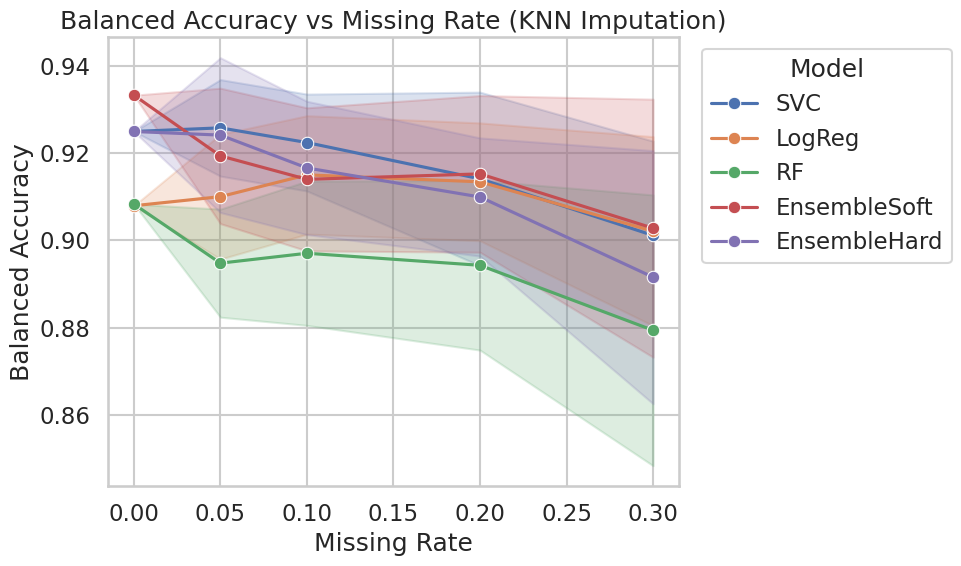

In [ ]:
df_knn = df[df["imputer"] == "KNN(k=5,dist)"].copy()

# ordem dos modelos
model_order = ["SVC", "LogReg", "RF", "EnsembleSoft", "EnsembleHard"]

# 3) gráfico de Balanced Accuracy
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_knn,
    x="missing_rate",
    y="bal_acc",
    hue="model",
    hue_order=model_order,
    marker="o",
    errorbar="sd"
)
plt.title("Balanced Accuracy vs Missing Rate (KNN Imputation)")
plt.xlabel("Missing Rate")
plt.ylabel("Balanced Accuracy")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("models_balacc_knn.png", dpi=300, bbox_inches="tight")
plt.savefig("models_balacc_knn.svg", bbox_inches="tight")
plt.show()

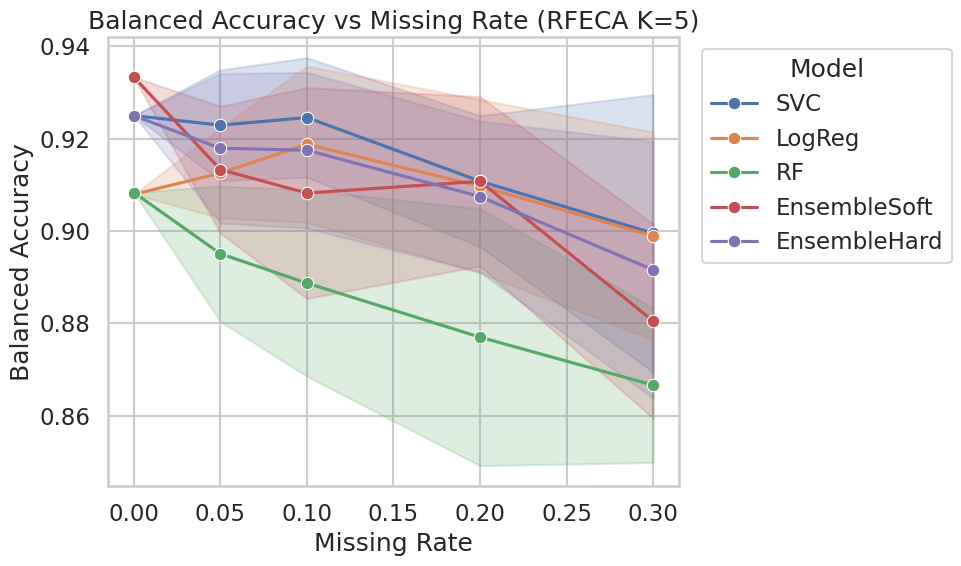

In [ ]:
df_knn = df[df["imputer"] == "RFECA_SVR(k=5)"].copy()

# ordem dos modelos
model_order = ["SVC", "LogReg", "RF", "EnsembleSoft", "EnsembleHard"]

# 3) gráfico de Balanced Accuracy
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_knn,
    x="missing_rate",
    y="bal_acc",
    hue="model",
    hue_order=model_order,
    marker="o",
    errorbar="sd"
)
plt.title("Balanced Accuracy vs Missing Rate (RFECA K=5)")
plt.xlabel("Missing Rate")
plt.ylabel("Balanced Accuracy")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("models_balacc_knn.png", dpi=300, bbox_inches="tight")
plt.savefig("models_balacc_knn.svg", bbox_inches="tight")
plt.show()

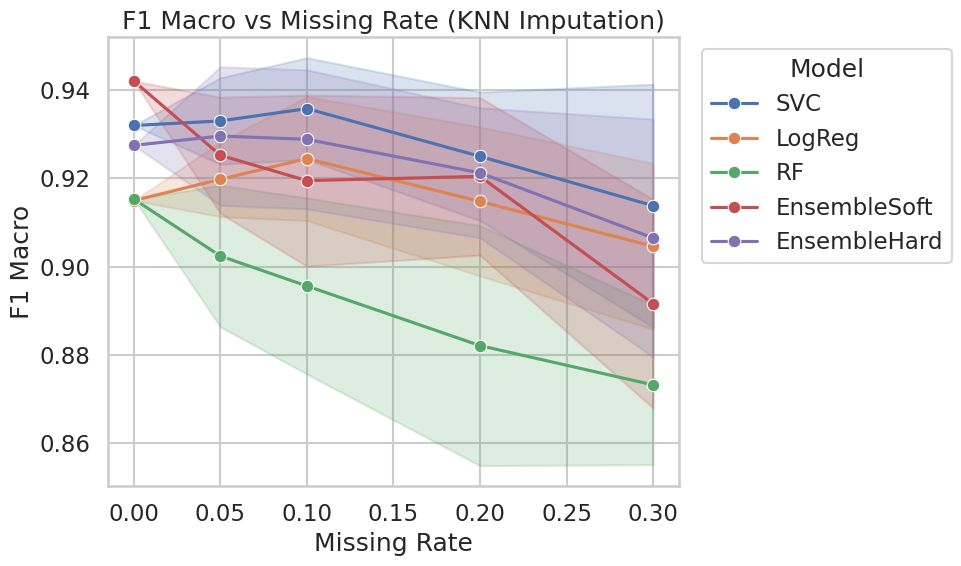

In [ ]:
# modelos que queremos mostrar (sem GB)
model_order = ["SVC", "LogReg", "RF", "EnsembleSoft", "EnsembleHard"]

df_plot = df_knn[df_knn["model"].isin(model_order)]

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df_plot,
    x="missing_rate",
    y="f1_macro",
    hue="model",
    hue_order=model_order,
    marker="o",
    errorbar="sd"
)

plt.title("F1 Macro vs Missing Rate (KNN Imputation)")
plt.xlabel("Missing Rate")
plt.ylabel("F1 Macro")

plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()

plt.savefig("models_f1_knn.png", dpi=300, bbox_inches="tight")
plt.savefig("models_f1_knn.svg", bbox_inches="tight")

plt.show()

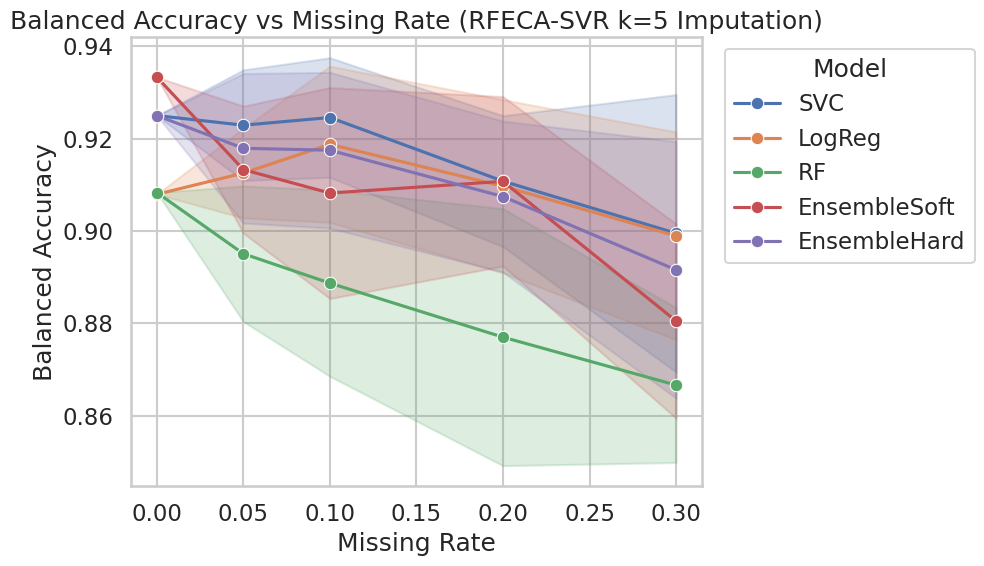

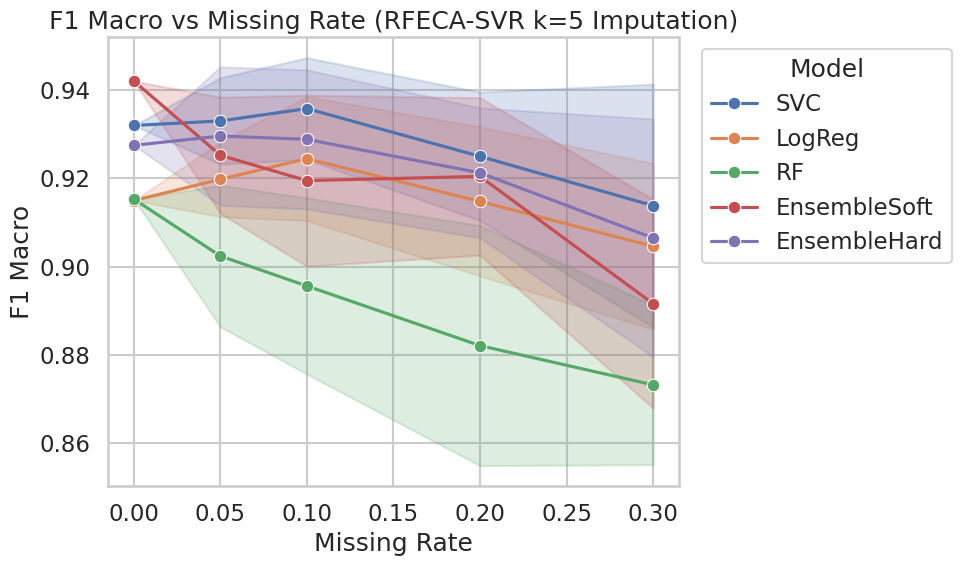

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", context="talk")

# carregar e consolidar
df1 = pd.read_csv("exp2_classification_raw(1).csv")
df2 = pd.read_csv("exp2_classification_raw(2).csv")
df3 = pd.read_csv("exp2_classification_raw(3).csv")
df4 = pd.read_csv("exp2_classification_raw(4).csv")

# remove RFECA k20 apenas do raw(1)
df1 = df1[df1["imputer"] != "RFECA_SVR(k=20)"]

df = pd.concat([df1, df2, df3, df4], ignore_index=True)

# fixar RFECA k=5
df_rfeca5 = df[df["imputer"] == "RFECA_SVR(k=5)"].copy()

# modelos sem GB
model_order = ["SVC", "LogReg", "RF", "EnsembleSoft", "EnsembleHard"]
df_plot = df_rfeca5[df_rfeca5["model"].isin(model_order)].copy()

# 1) Balanced Accuracy
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_plot,
    x="missing_rate",
    y="bal_acc",
    hue="model",
    hue_order=model_order,
    marker="o",
    errorbar="sd"
)
plt.title("Balanced Accuracy vs Missing Rate (RFECA-SVR k=5 Imputation)")
plt.xlabel("Missing Rate")
plt.ylabel("Balanced Accuracy")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("models_balacc_rfeca5.png", dpi=300, bbox_inches="tight")
plt.savefig("models_balacc_rfeca5.svg", bbox_inches="tight")
plt.show()

# 2) F1 Macro
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_plot,
    x="missing_rate",
    y="f1_macro",
    hue="model",
    hue_order=model_order,
    marker="o",
    errorbar="sd"
)
plt.title("F1 Macro vs Missing Rate (RFECA-SVR k=5 Imputation)")
plt.xlabel("Missing Rate")
plt.ylabel("F1 Macro")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("models_f1_rfeca5.png", dpi=300, bbox_inches="tight")
plt.savefig("models_f1_rfeca5.svg", bbox_inches="tight")
plt.show()

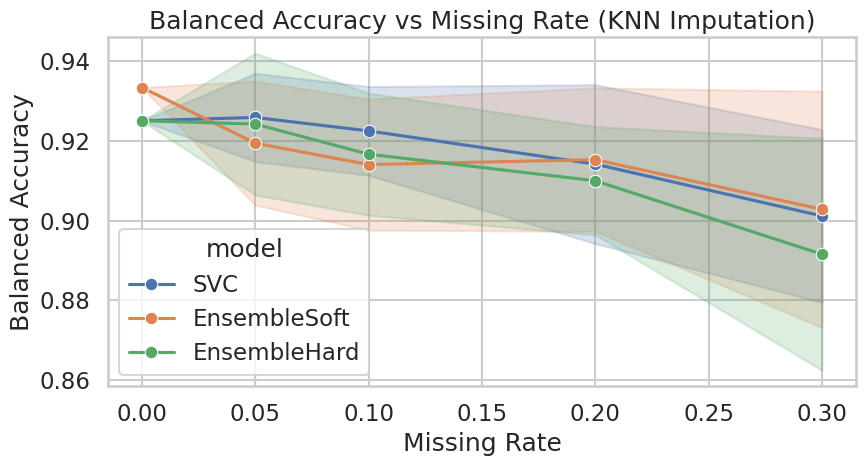

In [ ]:
focus_models = ["SVC", "EnsembleSoft", "EnsembleHard"]

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=df_knn[df_knn["model"].isin(focus_models)],
    x="missing_rate",
    y="bal_acc",
    hue="model",
    hue_order=focus_models,
    marker="o",
    errorbar="sd"
)
plt.title("Balanced Accuracy vs Missing Rate (KNN Imputation)")
plt.xlabel("Missing Rate")
plt.ylabel("Balanced Accuracy")
plt.tight_layout()
plt.show()

In [ ]:
summary_models = (
    df_knn.groupby(["model", "missing_rate"], as_index=False)
    .agg(
        bal_mean=("bal_acc", "mean"),
        bal_sd=("bal_acc", "std"),
        f1_mean=("f1_macro", "mean"),
        f1_sd=("f1_macro", "std"),
    )
)
print(summary_models.sort_values(["missing_rate", "bal_mean"], ascending=[True, False]))

           model  missing_rate  bal_mean    bal_sd   f1_mean     f1_sd
5   EnsembleSoft          0.00  0.933333  0.000000  0.941993  0.000000
0   EnsembleHard          0.00  0.925000  0.000000  0.927447  0.000000
25           SVC          0.00  0.925000  0.000000  0.931940  0.000000
20            RF          0.00  0.908333  0.000000  0.915273  0.000000
15        LogReg          0.00  0.907955  0.000000  0.914956  0.000000
10            GB          0.00  0.783333  0.000000  0.804242  0.000000
26           SVC          0.05  0.925833  0.011076  0.936773  0.011200
1   EnsembleHard          0.05  0.924167  0.017765  0.934513  0.015302
6   EnsembleSoft          0.05  0.919394  0.015548  0.928578  0.014803
16        LogReg          0.05  0.910038  0.014333  0.916260  0.011236
21            RF          0.05  0.894773  0.012404  0.901866  0.011595
11            GB          0.05  0.797258  0.035560  0.809624  0.037153
27           SVC          0.10  0.922462  0.011121  0.933690  0.011354
2   En

## Configuração e leitura dos dados

In [ ]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

sns.set(style="whitegrid", context="talk")

BASE_DIR = "/content/drive/MyDrive/semish"

IMP_RAW_FILE = "exp1_imputation_raw_cv.csv"
IMP_SUM_FILE = "exp1_imputation_summary_cv.csv"


def load_imputation_results(base_dir):

    imp_raw = pd.read_csv(os.path.join(base_dir, IMP_RAW_FILE))
    imp_sum = pd.read_csv(os.path.join(base_dir, IMP_SUM_FILE))

    # garantir tipos corretos
    imp_raw["missing_rate"] = imp_raw["missing_rate"].astype(float)
    imp_sum["missing_rate"] = imp_sum["missing_rate"].astype(float)

    # remover cenário 0% missing (não há imputação)
    imp_raw = imp_raw[imp_raw["missing_rate"] > 0].copy()
    imp_sum = imp_sum[imp_sum["missing_rate"] > 0].copy()

    return imp_raw, imp_sum


imp_raw, imp_sum = load_imputation_results(BASE_DIR)

print("Imputation raw:", imp_raw.shape)
print("Imputation summary:", imp_sum.shape)

Imputation raw: (1000, 7)
Imputation summary: (200, 9)


## RMSE vs Missing Rate

/tmp/ipykernel_587/3360377099.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(


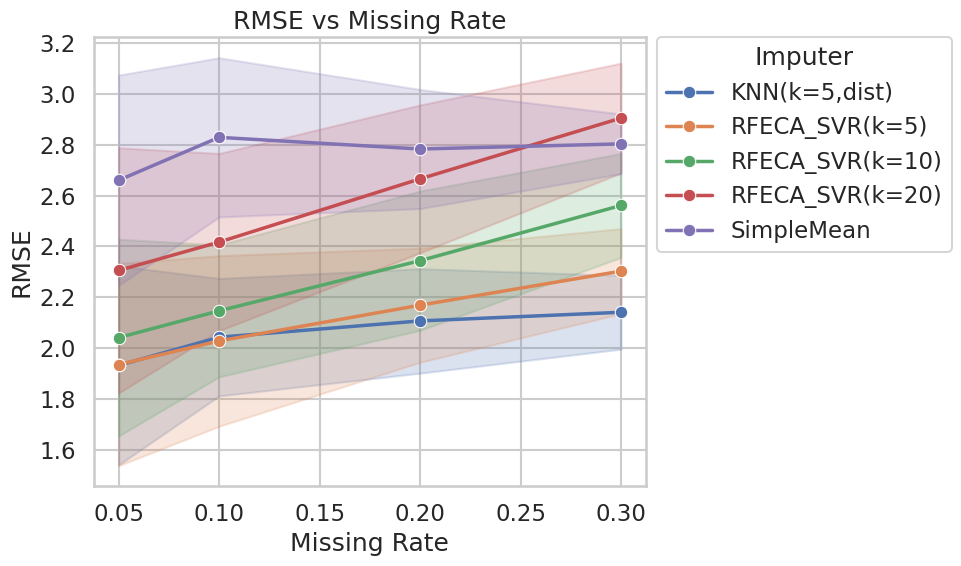

In [ ]:
plt.figure(figsize=(10,6))

order = [
    "KNN(k=5,dist)",
    "RFECA_SVR(k=5)",
    "RFECA_SVR(k=10)",
    "RFECA_SVR(k=20)",
    "SimpleMean"
]

sns.lineplot(
    data=imp_raw,
    x="missing_rate",
    y="rmse",
    hue="imputer",
    hue_order=order,
    marker="o",
    ci="sd",
    linewidth=2.5
)

plt.title("RMSE vs Missing Rate")
plt.xlabel("Missing Rate")
plt.ylabel("RMSE")

# legenda fora do gráfico
plt.legend(
    title="Imputer",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()

plt.savefig("rmse_vs_missing.png", dpi=300, bbox_inches="tight")
plt.savefig("rmse_vs_missing.svg", bbox_inches="tight")

plt.show()

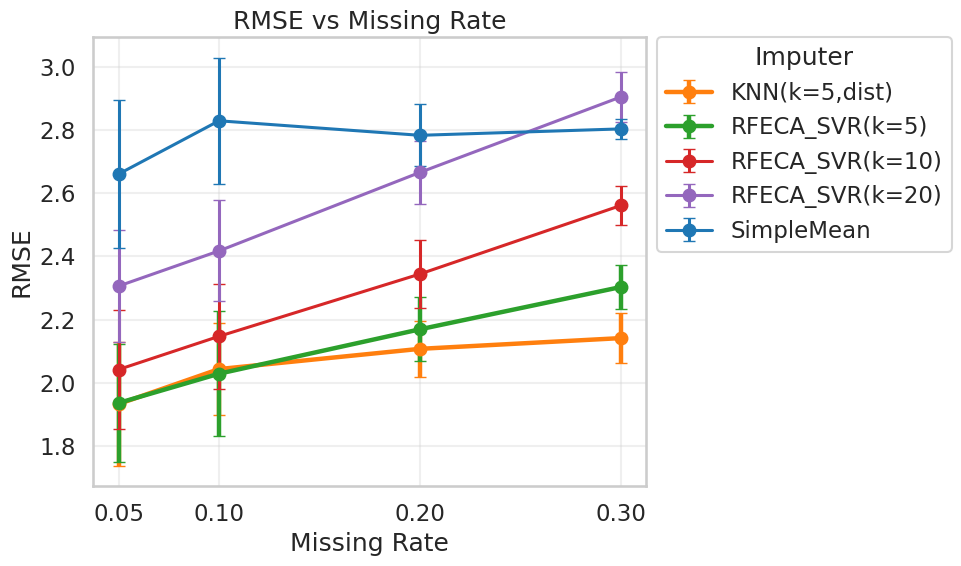

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# filtra cenários com missing real
plot_df = imp_summary_cv[imp_summary_cv["missing_rate"] > 0].copy()

# agrega por imputador e taxa de missing
plot_rmse = (
    plot_df
    .groupby(["imputer", "missing_rate"], as_index=False)
    .agg(
        rmse_mean=("rmse_mean", "mean"),
        rmse_sd=("rmse_mean", "std")
    )
)

order = [
    "KNN(k=5,dist)",
    "RFECA_SVR(k=5)",
    "RFECA_SVR(k=10)",
    "RFECA_SVR(k=20)",
    "SimpleMean"
]

palette = {
    "KNN(k=5,dist)": "tab:orange",
    "RFECA_SVR(k=5)": "tab:green",
    "RFECA_SVR(k=10)": "tab:red",
    "RFECA_SVR(k=20)": "tab:purple",
    "SimpleMean": "tab:blue",
}

linewidth_map = {
    "KNN(k=5,dist)": 3.2,
    "RFECA_SVR(k=5)": 3.2,
    "RFECA_SVR(k=10)": 2.2,
    "RFECA_SVR(k=20)": 2.2,
    "SimpleMean": 2.2,
}

plt.figure(figsize=(10, 6))

for imputer in order:
    group = plot_rmse[plot_rmse["imputer"] == imputer].sort_values("missing_rate")

    plt.errorbar(
        group["missing_rate"],
        group["rmse_mean"],
        yerr=group["rmse_sd"],
        marker="o",
        linewidth=linewidth_map[imputer],
        capsize=4,
        label=imputer,
        color=palette[imputer]
    )

plt.title("RMSE vs Missing Rate")
plt.xlabel("Missing Rate")
plt.ylabel("RMSE")
plt.xticks(sorted(plot_rmse["missing_rate"].unique()))

plt.legend(
    title="Imputer",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("rmse_vs_missing_errorbar.png", dpi=300, bbox_inches="tight")
plt.savefig("rmse_vs_missing_errorbar.svg", bbox_inches="tight")
plt.show()

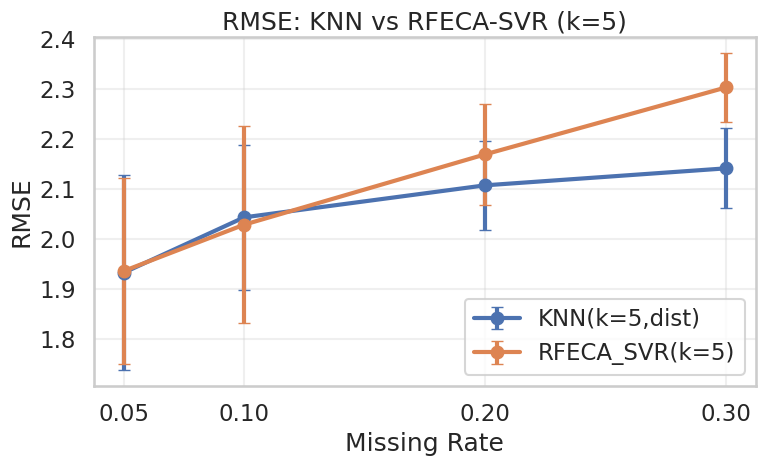

In [ ]:
focus = ["KNN(k=5,dist)", "RFECA_SVR(k=5)"]
focus_df = plot_rmse[plot_rmse["imputer"].isin(focus)].copy()

plt.figure(figsize=(8, 5))

for imputer in focus:
    group = focus_df[focus_df["imputer"] == imputer].sort_values("missing_rate")
    plt.errorbar(
        group["missing_rate"],
        group["rmse_mean"],
        yerr=group["rmse_sd"],
        marker="o",
        linewidth=3,
        capsize=4,
        label=imputer
    )

plt.title("RMSE: KNN vs RFECA-SVR (k=5)")
plt.xlabel("Missing Rate")
plt.ylabel("RMSE")
plt.xticks(sorted(focus_df["missing_rate"].unique()))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print(imp_raw["imputer"].unique())
print()
print(imp_raw.groupby(["experiment", "imputer"]).size())

['SimpleMean' 'KNN(k=5,dist)' 'RFECA_SVR(k=5)' 'RFECA_SVR(k=10)'
 'RFECA_SVR(k=20)']

experiment          imputer        
baseline_no_scaler  KNN(k=5,dist)      40
                    SimpleMean         40
rfeca_k10           RFECA_SVR(k=10)    40
rfeca_k20           RFECA_SVR(k=20)    40
rfeca_k5            RFECA_SVR(k=5)     40
dtype: int64


In [ ]:
summary = (
    imp_raw.groupby(["experiment", "imputer", "missing_rate"], as_index=False)
    .agg(
        rmse_mean=("rmse", "mean"),
        rmse_sd=("rmse", "std")
    )
)

print(summary.sort_values(["imputer", "experiment", "missing_rate"]))

            experiment          imputer  missing_rate  rmse_mean   rmse_sd
0   baseline_no_scaler    KNN(k=5,dist)          0.05   3.884672  0.803859
1   baseline_no_scaler    KNN(k=5,dist)          0.10   4.227500  0.599018
2   baseline_no_scaler    KNN(k=5,dist)          0.20   4.482373  0.390539
3   baseline_no_scaler    KNN(k=5,dist)          0.30   4.605930  0.348248
8            rfeca_k10  RFECA_SVR(k=10)          0.05   7.712392  1.186753
9            rfeca_k10  RFECA_SVR(k=10)          0.10   8.581336  1.053151
10           rfeca_k10  RFECA_SVR(k=10)          0.20   8.352098  0.590512
11           rfeca_k10  RFECA_SVR(k=10)          0.30   8.492700  0.115185
12           rfeca_k20  RFECA_SVR(k=20)          0.05   7.712392  1.186753
13           rfeca_k20  RFECA_SVR(k=20)          0.10   8.581336  1.053151
14           rfeca_k20  RFECA_SVR(k=20)          0.20   8.352098  0.590512
15           rfeca_k20  RFECA_SVR(k=20)          0.30   8.492700  0.115185
16            rfeca_k5   

In [ ]:
base = "/content/drive/MyDrive/semish"

df_k5 = pd.read_csv(os.path.join(base, "experimento 2 - k5 com scaler", "exp1_imputation_raw.csv"))
df_k10 = pd.read_csv(os.path.join(base, "experimento 3 - k10 com scaler", "exp1_imputation_raw.csv"))
df_k20 = pd.read_csv(os.path.join(base, "experimento 4 - k20 com scaler", "exp1_imputation_raw.csv"))

print("k5 == k10:", df_k5.equals(df_k10))
print("k5 == k20:", df_k5.equals(df_k20))
print("k10 == k20:", df_k10.equals(df_k20))

k5 == k10: False
k5 == k20: False
k10 == k20: False


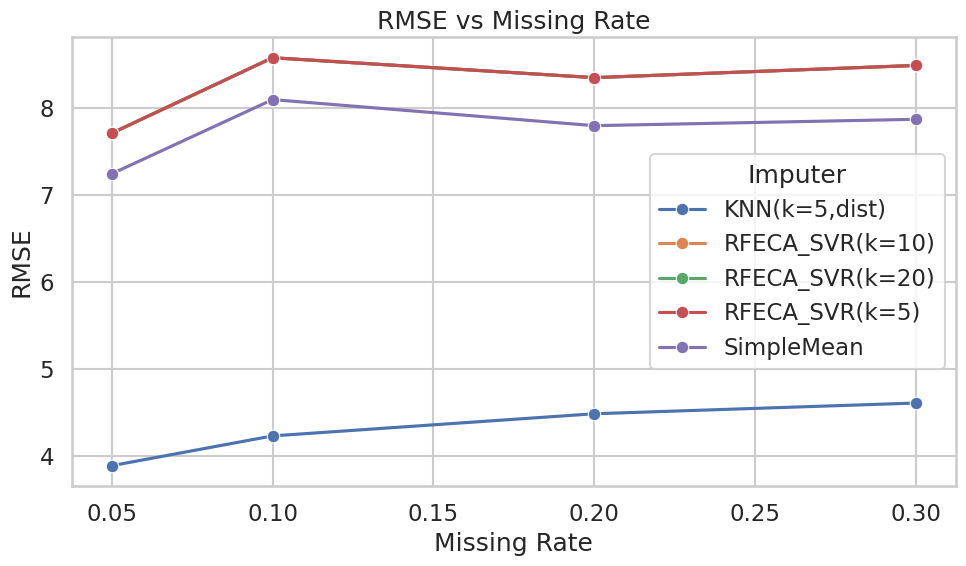

In [ ]:
summary = (
    imp_raw.groupby(["imputer", "missing_rate"], as_index=False)
    .agg(
        rmse_mean=("rmse", "mean"),
        rmse_sd=("rmse", "std")
    )
)

plt.figure(figsize=(10,6))

sns.lineplot(
    data=summary,
    x="missing_rate",
    y="rmse_mean",
    hue="imputer",
    marker="o",
    errorbar=None
)

plt.title("RMSE vs Missing Rate")
plt.xlabel("Missing Rate")
plt.ylabel("RMSE")
plt.legend(title="Imputer")
plt.tight_layout()
plt.show()

## MAE vs Missing Rate

/tmp/ipykernel_511/1221944750.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(


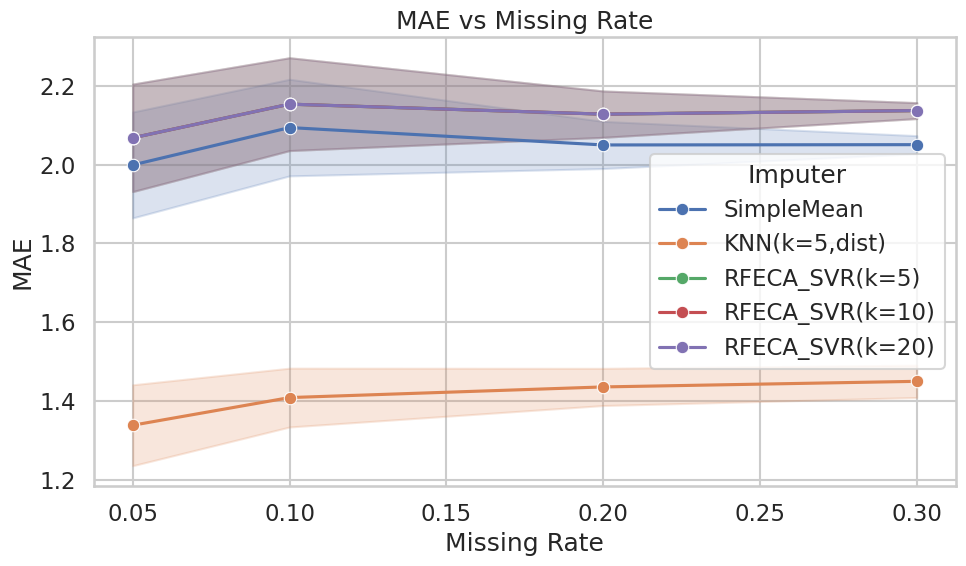

In [ ]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=imp_raw,
    x="missing_rate",
    y="mae",
    hue="imputer",
    marker="o",
    ci="sd"
)

plt.title("MAE vs Missing Rate")
plt.xlabel("Missing Rate")
plt.ylabel("MAE")
plt.legend(title="Imputer")
plt.tight_layout()

plt.savefig("mae_vs_missing.png", dpi=300)
plt.savefig("mae_vs_missing.svg")
plt.show()

## Gráfico de classificação

In [ ]:
cls_soft = cls_raw[cls_raw["model"] == "EnsembleSoft"]

## F1 vs Missing Rate

/tmp/ipykernel_511/1768992772.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(


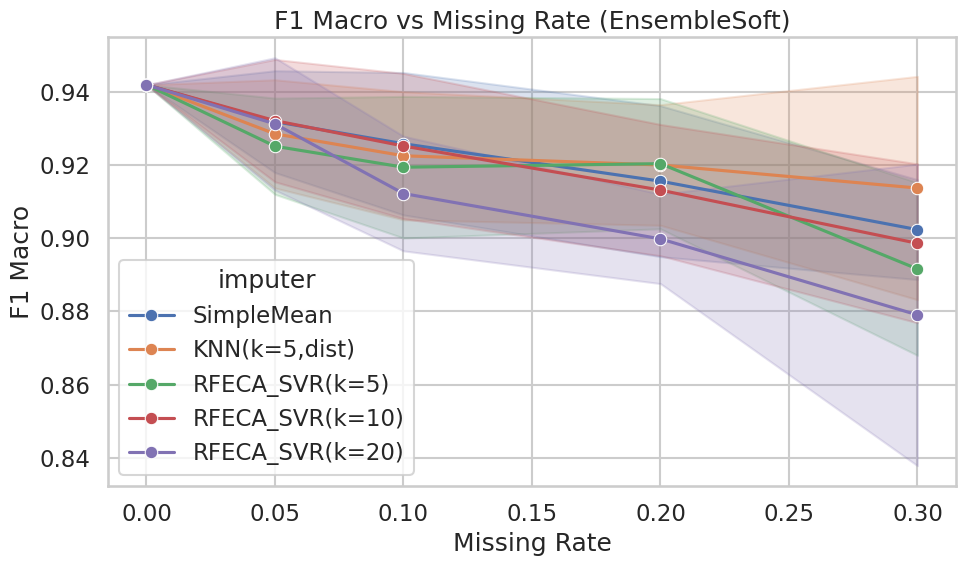

In [ ]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=cls_soft,
    x="missing_rate",
    y="f1_macro",
    hue="imputer",
    marker="o",
    ci="sd"
)

plt.title("F1 Macro vs Missing Rate (EnsembleSoft)")
plt.xlabel("Missing Rate")
plt.ylabel("F1 Macro")
plt.tight_layout()

plt.savefig("f1_vs_missing.png", dpi=300)
plt.savefig("f1_vs_missing.svg")
plt.show()

## Balanced Accuracy vs Missing Rate

/tmp/ipykernel_511/2480850838.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(


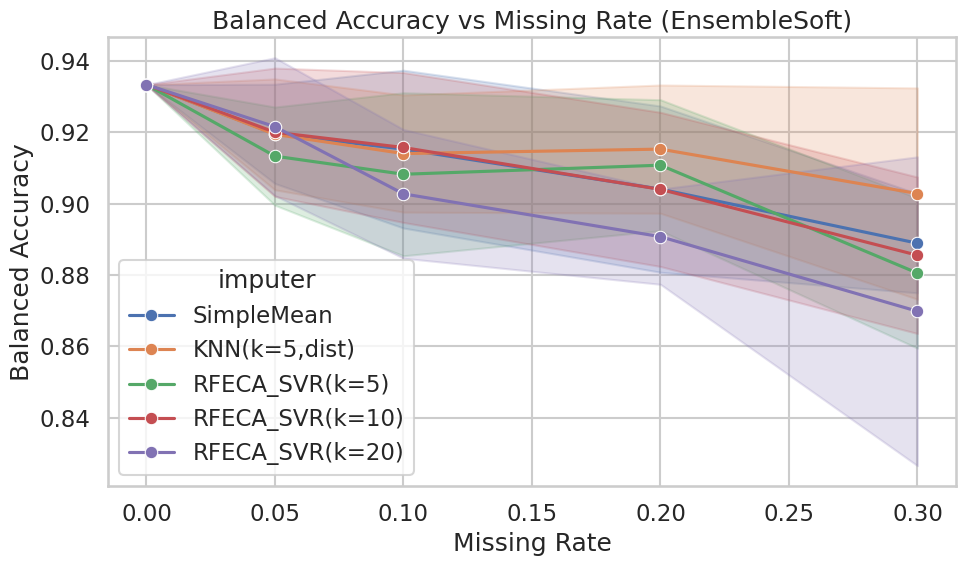

In [ ]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=cls_soft,
    x="missing_rate",
    y="bal_acc",
    hue="imputer",
    marker="o",
    ci="sd"
)

plt.title("Balanced Accuracy vs Missing Rate (EnsembleSoft)")
plt.xlabel("Missing Rate")
plt.ylabel("Balanced Accuracy")
plt.tight_layout()

plt.savefig("balacc_vs_missing.png", dpi=300)
plt.savefig("balacc_vs_missing.svg")
plt.show()

## Sensibilidade ao parâmetro k

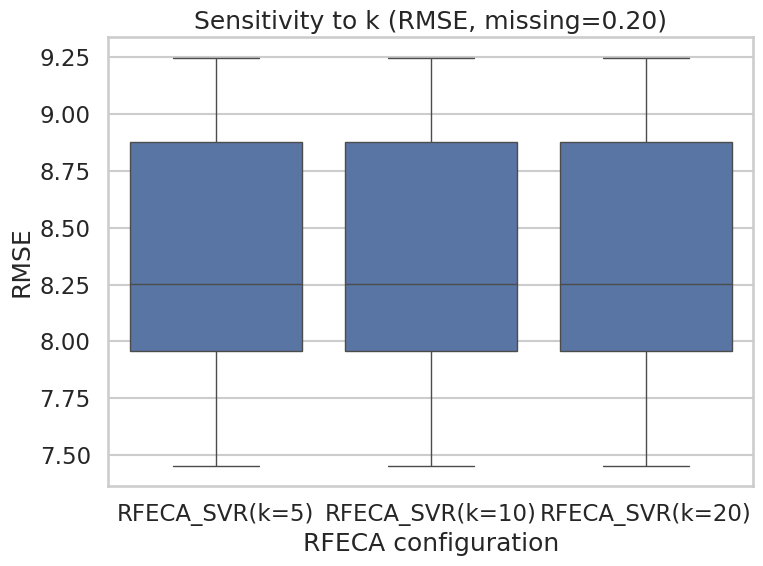

In [ ]:
subset = imp_raw[
    (imp_raw["missing_rate"] == 0.20) &
    (imp_raw["imputer"].str.contains("RFECA"))
]

plt.figure(figsize=(8,6))

sns.boxplot(
    data=subset,
    x="imputer",
    y="rmse"
)

plt.title("Sensitivity to k (RMSE, missing=0.20)")
plt.xlabel("RFECA configuration")
plt.ylabel("RMSE")

plt.tight_layout()
plt.savefig("rfeca_k_sensitivity.png", dpi=300)
plt.savefig("rfeca_k_sensitivity.svg")
plt.show()

## Teste estatístico (Wilcoxon pareado) - RMSE

In [ ]:
from scipy.stats import wilcoxon
import numpy as np
import pandas as pd

def wilcoxon_paired_by_replicate(
    df: pd.DataFrame,
    method_a: str,
    method_b: str,
    metric: str = "rmse",
    missing_rate: float = 0.20,
    group_cols=("replicate",),  # pode trocar para ("experiment","replicate") se quiser
    zero_method="wilcox",
    alternative="two-sided"
):
    # 1) filtra
    sub = df[df["missing_rate"] == missing_rate].copy()

    # 2) mantém apenas os dois métodos
    sub = sub[sub["imputer"].isin([method_a, method_b])]

    # 3) pivot: cada linha = replicate (ou experiment+replicate), colunas = métodos
    wide = sub.pivot_table(
        index=list(group_cols),
        columns="imputer",
        values=metric,
        aggfunc="mean"
    )

    # 4) pega somente pares completos
    wide = wide[[method_a, method_b]].dropna()

    n_pairs = len(wide)
    if n_pairs < 3:
        return {"p": np.nan, "n_pairs": n_pairs, "reason": "Poucos pares para Wilcoxon"}

    a = wide[method_a].to_numpy()
    b = wide[method_b].to_numpy()

    # 5) se forem idênticos em todos os pares, Wilcoxon pode falhar
    if np.allclose(a, b):
        return {"p": 1.0, "n_pairs": n_pairs, "reason": "Vetores idênticos"}

    stat, p = wilcoxon(a, b, zero_method=zero_method, alternative=alternative)
    return {"p": float(p), "n_pairs": n_pairs, "reason": ""}


def run_all_wilcoxon(
    df: pd.DataFrame,
    metric="rmse",
    missing_rates=(0.05, 0.10, 0.20, 0.30),
    group_cols=("replicate",)  # ou ("experiment","replicate")
):
    methods = sorted(df["imputer"].unique())
    rows = []
    for mr in missing_rates:
        for i in range(len(methods)):
            for j in range(i+1, len(methods)):
                m1, m2 = methods[i], methods[j]
                out = wilcoxon_paired_by_replicate(
                    df, m1, m2, metric=metric, missing_rate=mr, group_cols=group_cols
                )
                rows.append({
                    "missing_rate": mr,
                    "metric": metric,
                    "method_a": m1,
                    "method_b": m2,
                    "p_value": out["p"],
                    "n_pairs": out["n_pairs"],
                    "note": out["reason"]
                })
    return pd.DataFrame(rows).sort_values(["missing_rate", "p_value"])


# Exemplo: rodar para RMSE
wilcox_rmse = run_all_wilcoxon(
    imp_raw,
    metric="rmse",
    missing_rates=(0.05, 0.10, 0.20, 0.30),
    group_cols=("replicate",)  # se quiser separar por experimento: ("experiment","replicate")
)

wilcox_rmse.head(20)

,missing_rate,metric,method_a,method_b,p_value,n_pairs,note
0,0.05,rmse,"KNN(k=5,dist)",RFECA_SVR(k=10),0.001953,10,
1,0.05,rmse,"KNN(k=5,dist)",RFECA_SVR(k=20),0.001953,10,
2,0.05,rmse,"KNN(k=5,dist)",RFECA_SVR(k=5),0.001953,10,
3,0.05,rmse,"KNN(k=5,dist)",SimpleMean,0.001953,10,
6,0.05,rmse,RFECA_SVR(k=10),SimpleMean,0.001953,10,
8,0.05,rmse,RFECA_SVR(k=20),SimpleMean,0.001953,10,
9,0.05,rmse,RFECA_SVR(k=5),SimpleMean,0.001953,10,
4,0.05,rmse,RFECA_SVR(k=10),RFECA_SVR(k=20),1.000000,10,Vetores idênticos
5,0.05,rmse,RFECA_SVR(k=10),RFECA_SVR(k=5),1.000000,10,Vetores idênticos
7,0.05,rmse,RFECA_SVR(k=20),RFECA_SVR(k=5),1.000000,10,Vetores idênticos


In [ ]:
wilcox_rmse.to_csv("wilcoxon_rmse_results.csv", index=False)

## Wilcoxon MAE

In [ ]:
from scipy.stats import wilcoxon
import numpy as np
import pandas as pd

def wilcoxon_paired_by_replicate(
    df: pd.DataFrame,
    method_a: str,
    method_b: str,
    metric: str = "mae",
    missing_rate: float = 0.20,
    group_cols=("replicate",),  # pode trocar para ("experiment","replicate") se quiser
    zero_method="wilcox",
    alternative="two-sided"
):
    # 1) filtra
    sub = df[df["missing_rate"] == missing_rate].copy()

    # 2) mantém apenas os dois métodos
    sub = sub[sub["imputer"].isin([method_a, method_b])]

    # 3) pivot: cada linha = replicate (ou experiment+replicate), colunas = métodos
    wide = sub.pivot_table(
        index=list(group_cols),
        columns="imputer",
        values=metric,
        aggfunc="mean"
    )

    # 4) pega somente pares completos
    wide = wide[[method_a, method_b]].dropna()

    n_pairs = len(wide)
    if n_pairs < 3:
        return {"p": np.nan, "n_pairs": n_pairs, "reason": "Poucos pares para Wilcoxon"}

    a = wide[method_a].to_numpy()
    b = wide[method_b].to_numpy()

    # 5) se forem idênticos em todos os pares, Wilcoxon pode falhar
    if np.allclose(a, b):
        return {"p": 1.0, "n_pairs": n_pairs, "reason": "Vetores idênticos"}

    stat, p = wilcoxon(a, b, zero_method=zero_method, alternative=alternative)
    return {"p": float(p), "n_pairs": n_pairs, "reason": ""}


def run_all_wilcoxon(
    df: pd.DataFrame,
    metric="mae",
    missing_rates=(0.05, 0.10, 0.20, 0.30),
    group_cols=("replicate",)  # ou ("experiment","replicate")
):
    methods = sorted(df["imputer"].unique())
    rows = []
    for mr in missing_rates:
        for i in range(len(methods)):
            for j in range(i+1, len(methods)):
                m1, m2 = methods[i], methods[j]
                out = wilcoxon_paired_by_replicate(
                    df, m1, m2, metric=metric, missing_rate=mr, group_cols=group_cols
                )
                rows.append({
                    "missing_rate": mr,
                    "metric": metric,
                    "method_a": m1,
                    "method_b": m2,
                    "p_value": out["p"],
                    "n_pairs": out["n_pairs"],
                    "note": out["reason"]
                })
    return pd.DataFrame(rows).sort_values(["missing_rate", "p_value"])


# Exemplo: rodar para MAE
wilcox_mae = run_all_wilcoxon(
    imp_raw,
    metric="mae",
    missing_rates=(0.05, 0.10, 0.20, 0.30),
    group_cols=("replicate",)  # se quiser separar por experimento: ("experiment","replicate")
)

wilcox_mae.head(20)

,missing_rate,metric,method_a,method_b,p_value,n_pairs,note
0,0.05,mae,"KNN(k=5,dist)",RFECA_SVR(k=10),0.001953,10,
1,0.05,mae,"KNN(k=5,dist)",RFECA_SVR(k=20),0.001953,10,
2,0.05,mae,"KNN(k=5,dist)",RFECA_SVR(k=5),0.001953,10,
3,0.05,mae,"KNN(k=5,dist)",SimpleMean,0.001953,10,
6,0.05,mae,RFECA_SVR(k=10),SimpleMean,0.001953,10,
8,0.05,mae,RFECA_SVR(k=20),SimpleMean,0.001953,10,
9,0.05,mae,RFECA_SVR(k=5),SimpleMean,0.001953,10,
4,0.05,mae,RFECA_SVR(k=10),RFECA_SVR(k=20),1.000000,10,Vetores idênticos
5,0.05,mae,RFECA_SVR(k=10),RFECA_SVR(k=5),1.000000,10,Vetores idênticos
7,0.05,mae,RFECA_SVR(k=20),RFECA_SVR(k=5),1.000000,10,Vetores idênticos


In [ ]:
wilcox_mae["missing_rate"].unique()

array([0.05, 0.1 , 0.2 , 0.3 ])

In [ ]:
wilcox_mae.to_csv("wilcoxon_mae_results.csv", index=False)

## Tabela final para o paper

In [ ]:
table = cls_sum[
    cls_sum["model"] == "EnsembleSoft"
][[
    "imputer",
    "missing_rate",
    "f1_pm_std",
    "bal_pm_std"
]].sort_values(["missing_rate", "imputer"])

table.to_csv("paper_results_table.csv", index=False)

table

,imputer,missing_rate,f1_pm_std,bal_pm_std
0,"KNN(k=5,dist)",0.00,0.9420 ± 0.0000,0.9333 ± 0.0000
90,RFECA_SVR(k=10),0.00,0.9420 ± 0.0000,0.9333 ± 0.0000
120,RFECA_SVR(k=20),0.00,0.9420 ± 0.0000,0.9333 ± 0.0000
60,RFECA_SVR(k=5),0.00,0.9420 ± 0.0000,0.9333 ± 0.0000
30,SimpleMean,0.00,0.9420 ± 0.0000,0.9333 ± 0.0000
8,"KNN(k=5,dist)",0.05,0.9286 ± 0.0148,0.9194 ± 0.0155
97,RFECA_SVR(k=10),0.05,0.9322 ± 0.0167,0.9200 ± 0.0180
127,RFECA_SVR(k=20),0.05,0.9313 ± 0.0181,0.9216 ± 0.0193
68,RFECA_SVR(k=5),0.05,0.9252 ± 0.0132,0.9133 ± 0.0138
37,SimpleMean,0.05,0.9319 ± 0.0139,0.9195 ± 0.0139


## Wilcoxon para Classificação

In [ ]:
from scipy.stats import wilcoxon
import numpy as np
import pandas as pd

def wilcoxon_classification_paired(
    df: pd.DataFrame,
    method_a: str,
    method_b: str,
    metric: str = "f1_macro",
    model: str = "EnsembleSoft",
    missing_rate: float = 0.20,
    group_cols=("replicate",),
    zero_method="wilcox",
    alternative="two-sided"
):
    # 1) filtra missing rate e modelo
    sub = df[
        (df["missing_rate"] == missing_rate) &
        (df["model"] == model)
    ].copy()

    # 2) mantém apenas os dois imputadores
    sub = sub[sub["imputer"].isin([method_a, method_b])]

    # 3) pivot por replicate
    wide = sub.pivot_table(
        index=list(group_cols),
        columns="imputer",
        values=metric,
        aggfunc="mean"
    )

    # 4) manter só pares completos
    wide = wide[[method_a, method_b]].dropna()

    n_pairs = len(wide)
    if n_pairs < 3:
        return {"p": np.nan, "n_pairs": n_pairs, "reason": "Poucos pares para Wilcoxon"}

    a = wide[method_a].to_numpy()
    b = wide[method_b].to_numpy()

    if np.allclose(a, b):
        return {"p": 1.0, "n_pairs": n_pairs, "reason": "Vetores idênticos"}

    stat, p = wilcoxon(a, b, zero_method=zero_method, alternative=alternative)
    return {"p": float(p), "n_pairs": n_pairs, "reason": ""}

In [ ]:
def run_all_wilcoxon_classification(
    df: pd.DataFrame,
    metric="f1_macro",
    model="EnsembleSoft",
    missing_rates=(0.0, 0.05, 0.10, 0.20, 0.30),
    group_cols=("replicate",)
):
    methods = sorted(df["imputer"].unique())
    rows = []

    for mr in missing_rates:
        for i in range(len(methods)):
            for j in range(i + 1, len(methods)):
                m1, m2 = methods[i], methods[j]

                out = wilcoxon_classification_paired(
                    df=df,
                    method_a=m1,
                    method_b=m2,
                    metric=metric,
                    model=model,
                    missing_rate=mr,
                    group_cols=group_cols
                )

                rows.append({
                    "missing_rate": mr,
                    "model": model,
                    "metric": metric,
                    "method_a": m1,
                    "method_b": m2,
                    "p_value": out["p"],
                    "n_pairs": out["n_pairs"],
                    "note": out["reason"]
                })

    return pd.DataFrame(rows).sort_values(["missing_rate", "p_value"])

## F1 Macro

In [ ]:
wilcox_f1 = run_all_wilcoxon_classification(
    cls_raw,
    metric="f1_macro",
    model="EnsembleSoft",
    missing_rates=(0.0, 0.05, 0.10, 0.20, 0.30),
    group_cols=("replicate",)
)

wilcox_f1
wilcox_f1.to_csv("wilcoxon_f1_ensemble_soft.csv", index=False)

In [ ]:
wilcox_balacc = run_all_wilcoxon_classification(
    cls_raw,
    metric="bal_acc",
    model="EnsembleSoft",
    missing_rates=(0.0, 0.05, 0.10, 0.20, 0.30),
    group_cols=("replicate",)
)

wilcox_balacc
wilcox_balacc.to_csv("wilcoxon_balacc_ensemble_soft.csv", index=False)

## Matriz de confusão melhor modelo

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix
from sklearn.base import clone

# -------------------------
# Função principal
# -------------------------
def generate_confusion_matrix(
    X,
    y,
    pipeline,
    labels=None,
    n_splits=5,
    random_state=42,
    save_prefix="confusion_matrix"
):

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    all_preds = []
    all_true = []

    for train_idx, test_idx in cv.split(X, y):

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        model = clone(pipeline)
        model.fit(X_train, y_train)

        preds = model.predict(X_test)

        all_preds.extend(preds)
        all_true.extend(y_test)

    all_preds = np.array(all_preds)
    all_true = np.array(all_true)

    if labels is None:
        labels = sorted(np.unique(y))

    cm = confusion_matrix(all_true, all_preds, labels=labels)

    cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    # -------------------------
    # Matriz normal
    # -------------------------
    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")

    plt.tight_layout()

    plt.savefig(f"{save_prefix}_raw.png", dpi=300)
    plt.close()

    # -------------------------
    # Matriz normalizada
    # -------------------------
    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels
    )

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix (Normalized)")

    plt.tight_layout()

    plt.savefig(f"{save_prefix}_normalized.png", dpi=300)
    plt.close()

    return cm, cm_norm

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

ensemble_soft = VotingClassifier(
    estimators=[
        ("svc", SVC(kernel="rbf", probability=True)),
        ("lr", LogisticRegression(max_iter=5000)),
        ("rf", RandomForestClassifier(n_estimators=300)),
        ("gb", GradientBoostingClassifier())
    ],
    voting="soft"
)

best_pipeline = Pipeline([
    ("imputer", RFECAImputerSVR(
        corr_csv_path="correlation_table_pam50_full.csv",
        top_k=10,
        use_abs_corr=True
    )),
    ("scaler", StandardScaler()),
    ("clf", ensemble_soft)
])

In [ ]:
cm, cm_norm = generate_confusion_matrix(
    X_df_pam50_completo,
    y_df_pam50_completo,
    best_pipeline,
    save_prefix="pam50_best_pipeline"
)

In [ ]:
cm

array([[29,  0,  0,  0],
       [ 0, 13,  0,  1],
       [ 0,  0, 57,  0],
       [ 0,  0,  3, 14]])

## ultimo

In [ ]:
import os
import pandas as pd

# pasta base onde estão os diretórios dos experimentos
base_dir = "/content/drive/MyDrive/semish"

experiments = {
    "no_scaler": "experimento 1/exp2_classification_summary.csv",
    "k5_scaler": "experimento 2 - k5 com scaler/exp2_classification_summary.csv",
    "k10_scaler": "experimento 3 - k10 com scaler/exp2_classification_summary.csv",
    "k20_scaler": "experimento 4 - k20 com scaler/exp2_classification_summary.csv"
}

# pasta de saída
output_dir = "paper_tables"
os.makedirs(output_dir, exist_ok=True)

# -------------------------
# 1) Carregar todos os experimentos
# -------------------------
dfs = []

for exp_name, rel_path in experiments.items():
    full_path = os.path.join(base_dir, rel_path)
    df = pd.read_csv(full_path)
    df["experiment"] = exp_name
    dfs.append(df)

cls_sum = pd.concat(dfs, ignore_index=True)

# -------------------------
# 2) Remover o RFECA k20 sem scaler da execução antiga
# (mantém SimpleMean e KNN da execução antiga)
# -------------------------
cls_sum = cls_sum[
    ~(
        (cls_sum["experiment"] == "no_scaler") &
        (cls_sum["imputer"] == "RFECA_SVR(k=20)")
    )
].copy()

# -------------------------
# 3) CSV completo de comparação de classificadores
# -------------------------
classifier_comparison_full = cls_sum[
    [
        "experiment", "imputer", "missing_rate", "model",
        "f1_mean", "f1_std", "bal_mean", "bal_std",
        "f1_pm_std", "bal_pm_std", "n"
    ]
].copy()

classifier_comparison_full.to_csv(
    os.path.join(output_dir, "classifier_comparison_full.csv"),
    index=False
)

# -------------------------
# 4) Melhor classificador por imputador + missing_rate
# -------------------------
best_by_missing = (
    cls_sum
    .sort_values(
        ["experiment", "imputer", "missing_rate", "f1_mean"],
        ascending=[True, True, True, False]
    )
    .groupby(["experiment", "imputer", "missing_rate"], as_index=False)
    .first()
)

best_by_missing.to_csv(
    os.path.join(output_dir, "classifier_comparison_best_by_missing.csv"),
    index=False
)

# -------------------------
# 5) Tabela pivô de F1 para paper
# linhas = (experiment, imputer, missing_rate)
# colunas = modelos
# valores = f1_pm_std
# -------------------------
pivot_f1 = cls_sum.pivot_table(
    index=["experiment", "imputer", "missing_rate"],
    columns="model",
    values="f1_pm_std",
    aggfunc="first"
).reset_index()

pivot_f1.to_csv(
    os.path.join(output_dir, "classifier_comparison_pivot_f1.csv"),
    index=False
)

# -------------------------
# 6) Tabela pivô de Balanced Accuracy para paper
# -------------------------
pivot_bal = cls_sum.pivot_table(
    index=["experiment", "imputer", "missing_rate"],
    columns="model",
    values="bal_pm_std",
    aggfunc="first"
).reset_index()

pivot_bal.to_csv(
    os.path.join(output_dir, "classifier_comparison_pivot_balacc.csv"),
    index=False
)

# -------------------------
# 7) (opcional) Apenas EnsembleSoft para o paper
# -------------------------
ensemble_soft_table = cls_sum[
    cls_sum["model"] == "EnsembleSoft"
][[
    "experiment", "imputer", "missing_rate", "f1_pm_std", "bal_pm_std"
]].sort_values(["experiment", "missing_rate", "imputer"])

ensemble_soft_table.to_csv(
    os.path.join(output_dir, "classifier_comparison_ensemble_soft_only.csv"),
    index=False
)

# -------------------------
# 8) Preview
# -------------------------
print("Arquivos exportados em:", output_dir)

print("\nExperimentos carregados:")
print(cls_sum["experiment"].unique())

print("\nImputers encontrados:")
print(cls_sum["imputer"].unique())

print("\nPreview - best_by_missing:")
print(best_by_missing[
    ["experiment", "imputer", "missing_rate", "model", "f1_pm_std", "bal_pm_std"]
].head(20))

Arquivos exportados em: paper_tables

Experimentos carregados:
['no_scaler' 'k5_scaler' 'k10_scaler' 'k20_scaler']

Imputers encontrados:
['KNN(k=5,dist)' 'SimpleMean' 'RFECA_SVR(k=5)' 'RFECA_SVR(k=10)'
 'RFECA_SVR(k=20)']

Preview - best_by_missing:
    experiment          imputer  missing_rate         model        f1_pm_std  \
0   k10_scaler  RFECA_SVR(k=10)          0.00  EnsembleSoft  0.9420 ± 0.0000   
1   k10_scaler  RFECA_SVR(k=10)          0.05           SVC  0.9326 ± 0.0079   
2   k10_scaler  RFECA_SVR(k=10)          0.10  EnsembleHard  0.9353 ± 0.0133   
3   k10_scaler  RFECA_SVR(k=10)          0.20           SVC  0.9282 ± 0.0202   
4   k10_scaler  RFECA_SVR(k=10)          0.30  EnsembleHard  0.9026 ± 0.0252   
5   k20_scaler  RFECA_SVR(k=20)          0.00  EnsembleSoft  0.9420 ± 0.0000   
6   k20_scaler  RFECA_SVR(k=20)          0.05           SVC  0.9320 ± 0.0106   
7   k20_scaler  RFECA_SVR(k=20)          0.10           SVC  0.9309 ± 0.0143   
8   k20_scaler  RFECA_SVR(k=2

In [ ]:
target_imputer = "KNN(k=5,dist)"
cls_sum_knn = cls_sum[cls_sum["imputer"] == target_imputer].copy()

cls_sum_knn.to_csv(
    os.path.join(output_dir, "classifier_comparison_knn_only.csv"),
    index=False
)

NameError: name 'cls_sum' is not defined

In [ ]:
target_model = "EnsembleSoft"
cls_sum_ens = cls_sum[cls_sum["model"] == target_model].copy()

cls_sum_ens.to_csv(
    os.path.join(output_dir, "classifier_comparison_ensemble_soft_only.csv"),
    index=False
)

#new

In [1]:
import pandas as pd

imp = pd.read_csv("exp1_imputation_raw_cv(3).csv")

# remover missing_rate = 0 da tabela principal de imputação
imp = imp[imp["missing_rate"] > 0].copy()

imp_table = (
    imp.groupby(["missing_rate", "imputer"])
    .agg(
        rmse_mean=("rmse_mean", "mean"),
        rmse_std=("rmse_mean", "std"),
        mae_mean=("mae_mean", "mean"),
        mae_std=("mae_mean", "std"),
    )
    .reset_index()
)

imp_table["RMSE"] = imp_table.apply(lambda x: f"{x.rmse_mean:.4f} $\\pm$ {x.rmse_std:.4f}", axis=1)
imp_table["MAE"] = imp_table.apply(lambda x: f"{x.mae_mean:.4f} $\\pm$ {x.mae_std:.4f}", axis=1)

imp_table = imp_table[["missing_rate", "imputer", "RMSE", "MAE"]]

imp_table.to_csv("paper_table_imputation.csv", index=False)

latex_imp = imp_table.to_latex(index=False, escape=False, caption="Imputation performance across missing rates.", label="tab:imputation")
with open("paper_table_imputation.tex", "w") as f:
    f.write(latex_imp)

KeyError: "Column(s) ['mae_mean', 'rmse_mean'] do not exist"

In [2]:
import pandas as pd

cls = pd.read_csv("exp2_classification_raw_all(1).csv")

cls_table = (
    cls.groupby(["missing_rate", "imputer", "model"])
    .agg(
        f1_mean=("f1_macro", "mean"),
        f1_std=("f1_macro", "std"),
        bal_mean=("bal_acc", "mean"),
        bal_std=("bal_acc", "std"),
    )
    .reset_index()
)

# pegar o melhor classificador por imputador e missing rate
best_cls = (
    cls_table.sort_values(["missing_rate", "imputer", "f1_mean"], ascending=[True, True, False])
    .groupby(["missing_rate", "imputer"], as_index=False)
    .first()
)

best_cls["F1 Macro"] = best_cls.apply(lambda x: f"{x.f1_mean:.4f} $\\pm$ {x.f1_std:.4f}", axis=1)
best_cls["Balanced Accuracy"] = best_cls.apply(lambda x: f"{x.bal_mean:.4f} $\\pm$ {x.bal_std:.4f}", axis=1)

best_cls = best_cls[["missing_rate", "imputer", "model", "F1 Macro", "Balanced Accuracy"]]
best_cls = best_cls.rename(columns={"model": "Best classifier"})

best_cls.to_csv("paper_table_classification.csv", index=False)

latex_cls = best_cls.to_latex(index=False, escape=False, caption="Best classification results by imputer and missing rate.", label="tab:classification")
with open("paper_table_classification.tex", "w") as f:
    f.write(latex_cls)

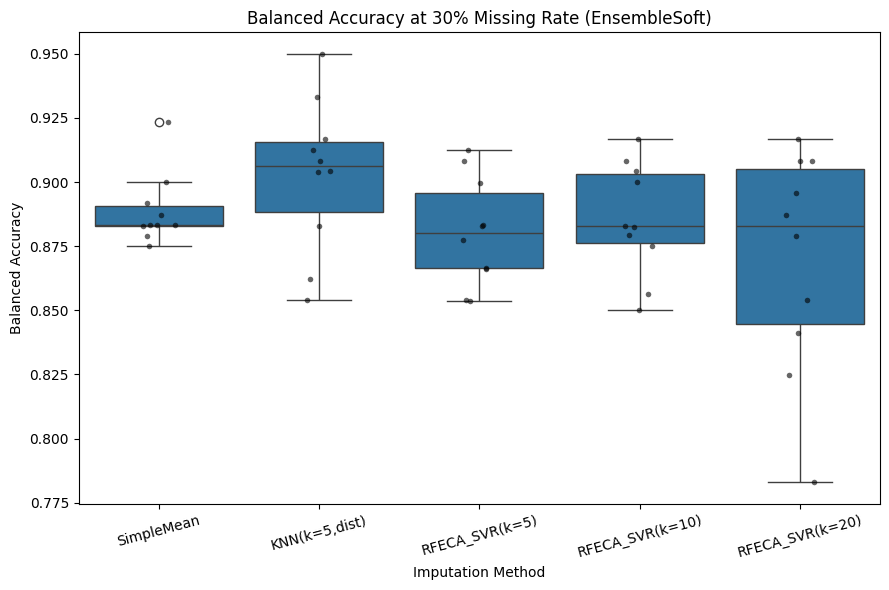

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cls = pd.read_csv("exp2_classification_raw_all(1).csv")

# foco no pior cenário e no modelo de interesse
cls_30 = cls[
    (cls["missing_rate"] == 0.30) &
    (cls["model"] == "EnsembleSoft")
].copy()

order = ["SimpleMean", "KNN(k=5,dist)", "RFECA_SVR(k=5)", "RFECA_SVR(k=10)", "RFECA_SVR(k=20)"]

plt.figure(figsize=(9,6))
sns.boxplot(
    data=cls_30,
    x="imputer",
    y="bal_acc",
    order=order
)
sns.stripplot(
    data=cls_30,
    x="imputer",
    y="bal_acc",
    order=order,
    color="black",
    alpha=0.6,
    size=4
)

plt.title("Balanced Accuracy at 30% Missing Rate (EnsembleSoft)")
plt.xlabel("Imputation Method")
plt.ylabel("Balanced Accuracy")
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig("boxplot_balacc_30_ensemble_soft.png", dpi=300, bbox_inches="tight")
plt.savefig("boxplot_balacc_30_ensemble_soft.svg", bbox_inches="tight")
plt.show()

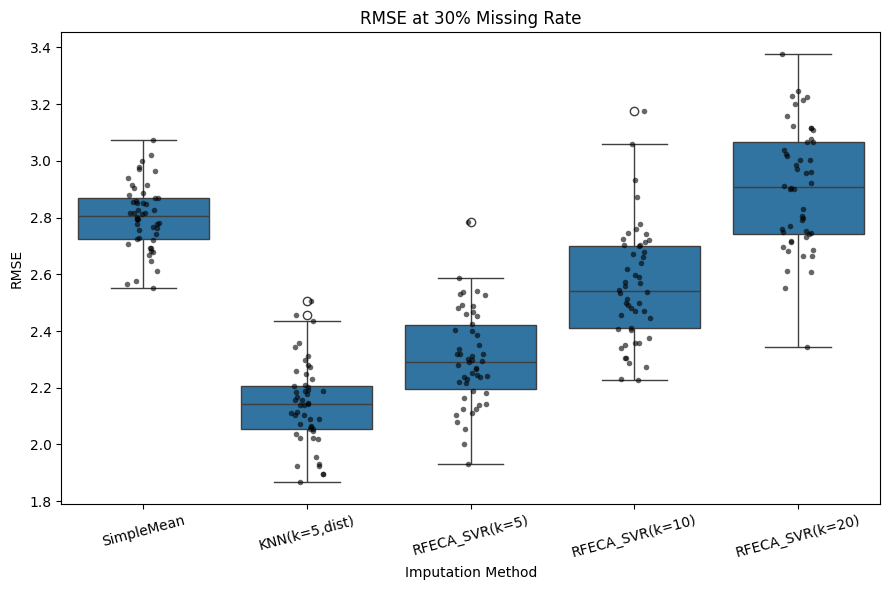

In [4]:
imp = pd.read_csv("exp1_imputation_raw_cv(3).csv")

imp_30 = imp[
    (imp["missing_rate"] == 0.30) &
    (imp["rmse"].notna())
].copy()

order = ["SimpleMean", "KNN(k=5,dist)", "RFECA_SVR(k=5)", "RFECA_SVR(k=10)", "RFECA_SVR(k=20)"]

plt.figure(figsize=(9,6))
sns.boxplot(
    data=imp_30,
    x="imputer",
    y="rmse",
    order=order
)
sns.stripplot(
    data=imp_30,
    x="imputer",
    y="rmse",
    order=order,
    color="black",
    alpha=0.6,
    size=4
)

plt.title("RMSE at 30% Missing Rate")
plt.xlabel("Imputation Method")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig("boxplot_rmse_30.png", dpi=300, bbox_inches="tight")
plt.savefig("boxplot_rmse_30.svg", bbox_inches="tight")
plt.show()

In [6]:
import pandas as pd

wilcox_rmse = pd.read_csv("wilcoxon_rmse_results(1).csv")

# manter apenas comparações úteis
wilcox_rmse = wilcox_rmse[["missing_rate", "method_a", "method_b", "p_value", "n_pairs"]].copy()
wilcox_rmse["p_value"] = wilcox_rmse["p_value"].map(lambda x: f"{x:.4f}")

latex_rmse = wilcox_rmse.to_latex(
    index=False,
    escape=False,
    caption="Wilcoxon signed-rank test for RMSE across imputers.",
    label="tab:wilcoxon_rmse"
)

with open("wilcoxon_rmse_table.tex", "w") as f:
    f.write(latex_rmse)

wilcox_rmse.head(20)

,missing_rate,method_a,method_b,p_value,n_pairs
0,0.05,"KNN(k=5,dist)",RFECA_SVR(k=10),0.0020,10
1,0.05,"KNN(k=5,dist)",RFECA_SVR(k=20),0.0020,10
2,0.05,"KNN(k=5,dist)",RFECA_SVR(k=5),0.0020,10
3,0.05,"KNN(k=5,dist)",SimpleMean,0.0020,10
4,0.05,RFECA_SVR(k=10),SimpleMean,0.0020,10
5,0.05,RFECA_SVR(k=20),SimpleMean,0.0020,10
6,0.05,RFECA_SVR(k=5),SimpleMean,0.0020,10
7,0.05,RFECA_SVR(k=10),RFECA_SVR(k=20),1.0000,10
8,0.05,RFECA_SVR(k=10),RFECA_SVR(k=5),1.0000,10
9,0.05,RFECA_SVR(k=20),RFECA_SVR(k=5),1.0000,10


In [7]:
wilcox_f1 = pd.read_csv("wilcoxon_f1_ensemble_soft(1).csv")

wilcox_f1 = wilcox_f1[["missing_rate", "method_a", "method_b", "p_value", "n_pairs"]].copy()
wilcox_f1["p_value"] = wilcox_f1["p_value"].map(lambda x: f"{x:.4f}")

latex_f1 = wilcox_f1.to_latex(
    index=False,
    escape=False,
    caption="Wilcoxon signed-rank test for macro F1 across imputers using EnsembleSoft.",
    label="tab:wilcoxon_f1"
)

with open("wilcoxon_f1_table.tex", "w") as f:
    f.write(latex_f1)

wilcox_f1.head(20)

,missing_rate,method_a,method_b,p_value,n_pairs
0,0.00,"KNN(k=5,dist)",RFECA_SVR(k=10),1.0000,10
1,0.00,"KNN(k=5,dist)",RFECA_SVR(k=20),1.0000,10
2,0.00,"KNN(k=5,dist)",RFECA_SVR(k=5),1.0000,10
3,0.00,"KNN(k=5,dist)",SimpleMean,1.0000,10
4,0.00,RFECA_SVR(k=10),RFECA_SVR(k=20),1.0000,10
5,0.00,RFECA_SVR(k=10),RFECA_SVR(k=5),1.0000,10
6,0.00,RFECA_SVR(k=10),SimpleMean,1.0000,10
7,0.00,RFECA_SVR(k=20),RFECA_SVR(k=5),1.0000,10
8,0.00,RFECA_SVR(k=20),SimpleMean,1.0000,10
9,0.00,RFECA_SVR(k=5),SimpleMean,1.0000,10


In [8]:
wilcox_rmse_30 = wilcox_rmse[wilcox_rmse["missing_rate"] == 0.30].copy()
wilcox_f1_30 = wilcox_f1[wilcox_f1["missing_rate"] == 0.30].copy()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

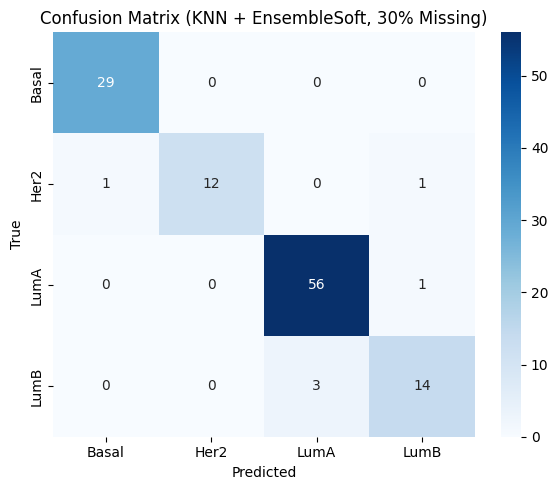

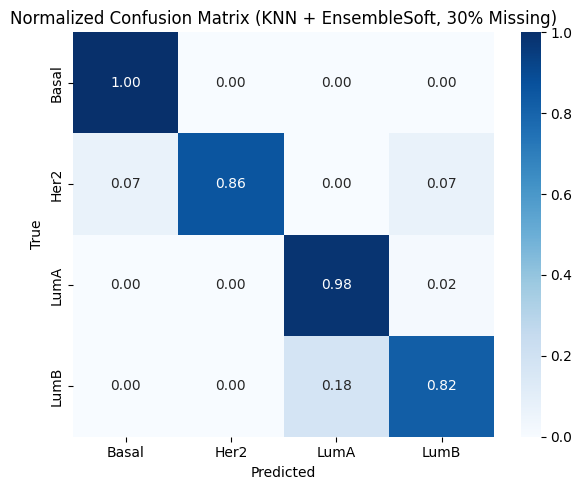

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix
from sklearn.base import clone

# -------------------------
# escolha do pipeline
# -------------------------
target_missing_rate = 0.30

imputer = KNNImputer(
    n_neighbors=5,
    weights="distance",
    metric="nan_euclidean"
)

pipelines = make_pipelines_with_imputer(imputer, random_state=42)
best_pipeline = pipelines["EnsembleSoft"]   # troque para "SVC" se quiser

X_missing = X_missing_sets[target_missing_rate][0]  # replicate 0
y = pd.Series(y_df_pam50_completo).reset_index(drop=True)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_true = []
all_pred = []

for train_idx, test_idx in cv.split(X_missing, y):
    X_train = X_missing.iloc[train_idx]
    X_test  = X_missing.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test  = y.iloc[test_idx]

    model = clone(best_pipeline)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    all_true.extend(y_test)
    all_pred.extend(preds)

all_true = np.array(all_true)
all_pred = np.array(all_pred)

labels = sorted(np.unique(y))
cm = confusion_matrix(all_true, all_pred, labels=labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

# -------------------------
# matriz bruta
# -------------------------
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (KNN + EnsembleSoft, 30% Missing)")
plt.tight_layout()
plt.savefig("confusion_matrix_knn_ensemble_30_raw.png", dpi=300, bbox_inches="tight")
plt.savefig("confusion_matrix_knn_ensemble_30_raw.svg", bbox_inches="tight")
plt.show()

# -------------------------
# matriz normalizada
# -------------------------
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix (KNN + EnsembleSoft, 30% Missing)")
plt.tight_layout()
plt.savefig("confusion_matrix_knn_ensemble_30_norm.png", dpi=300, bbox_inches="tight")
plt.savefig("confusion_matrix_knn_ensemble_30_norm.svg", bbox_inches="tight")
plt.show()

In [17]:
import pandas as pd

imp = pd.read_csv("exp1_imputation_summary_cv(3).csv")

# pegar melhor método por missing rate
best_imp = (
    imp.sort_values(["missing_rate", "rmse_mean"])
    .groupby("missing_rate", as_index=False)
    .first()
)

best_imp["RMSE"] = best_imp.apply(lambda x: f"{x.rmse_mean:.4f} ± {x.rmse_std:.4f}", axis=1)
best_imp["MAE"] = best_imp.apply(lambda x: f"{x.mae_mean:.4f} ± {x.mae_std:.4f}", axis=1)

best_imp = best_imp[["missing_rate", "imputer", "RMSE", "MAE"]]
print(best_imp)

   missing_rate         imputer             RMSE              MAE
0          0.00      SimpleMean        nan ± nan        nan ± nan
1          0.05  RFECA_SVR(k=5)  1.6625 ± 0.1663  1.1821 ± 0.1278
2          0.10  RFECA_SVR(k=5)  1.7902 ± 0.0955  1.2504 ± 0.0673
3          0.20   KNN(k=5,dist)  1.9936 ± 0.1758  1.3703 ± 0.0492
4          0.30   KNN(k=5,dist)  2.0682 ± 0.1657  1.3915 ± 0.1054
